# 05 — Risk-Neutral Monte Carlo and Discrete Delta-Hedging Error

This notebook closes the first Black-Scholes foundation block by connecting three equivalent views of derivative pricing:

1. **Replication:** an option price is determined by a self-financing hedge, not by a forecast.
2. **Risk-neutral valuation:** the same price can be written as a discounted expected payoff under the risk-neutral measure.
3. **Discrete hedging:** continuous-time replication is exact in theory, but real hedging is only approximate because rebalancing happens at discrete times.

The previous notebooks built the required sequence:

| Notebook | Role |
|---|---|
| `01_binomial_no_arbitrage_replication.ipynb` | Discrete no-arbitrage pricing and replication |
| `02_brownian_motion_gbm_and_quadratic_variation.ipynb` | Brownian motion, GBM, and quadratic variation |
| `03_ito_lemma_and_black_scholes_pde.ipynb` | Itô's lemma, delta hedging, and the Black-Scholes PDE |
| `04_black_scholes_formula_greeks_and_numerical_checks.ipynb` | Closed-form Black-Scholes prices, Greeks, and numerical validation |

This notebook does **not** use market data, implied volatility surfaces, SVI, Heston, Bates, macro factors, or calibration. It stays inside the Black-Scholes-Merton model so that the pricing logic is clean before moving to empirical option-chain work.

---

## Core question

If Black-Scholes was derived from replication, why can the same option price also be computed as a discounted expectation under the risk-neutral measure?

$$
V_0 = e^{-rT}\mathbb{E}^{Q}\left[\text{payoff}(S_T)\right]
$$

And if continuous replication is theoretically exact, what happens when the hedge is rebalanced only daily, weekly, or monthly?

---

## Model setup

Under the physical measure \(P\), the stock follows:

$$
dS_t = \mu S_t\,dt + \sigma S_t\,dW_t^{P}
$$

The drift \(\mu\) describes the real-world expected return. It is relevant for forecasting, but it is not the direct input to no-arbitrage option pricing.

Under the risk-neutral measure \(Q\), the stock follows:

$$
dS_t = (r-q)S_t\,dt + \sigma S_t\,dW_t^{Q}
$$

where:

| Symbol | Meaning |
|---|---|
| \(r\) | continuously compounded risk-free rate |
| \(q\) | continuous dividend yield |
| \(\sigma\) | volatility |
| \(W_t^Q\) | Brownian motion under the risk-neutral measure |

For a European call option:

$$
C_0 = e^{-rT}\mathbb{E}^{Q}\left[(S_T-K)^+\right]
$$

For a European put option:

$$
P_0 = e^{-rT}\mathbb{E}^{Q}\left[(K-S_T)^+\right]
$$

This notebook will verify numerically that Monte Carlo pricing under \(Q\) converges to the Black-Scholes-Merton formula, while Monte Carlo pricing under the physical drift \(\mu\) generally does **not** give the no-arbitrage price.

---

## Notebook structure

1. Define model configuration and baseline assumptions.
2. Reuse the Black-Scholes-Merton formula as the closed-form benchmark.
3. Simulate GBM under both \(P\) and \(Q\).
4. Verify the discounted-stock martingale property under \(Q\).
5. Price European calls and puts by risk-neutral Monte Carlo.
6. Compare risk-neutral Monte Carlo with physical-drift Monte Carlo.
7. Add a basic antithetic-variates variance-reduction check.
8. Run a single-path delta-hedging demonstration.
9. Simulate discrete delta-hedging error across many paths.
10. Test how hedging error changes with rebalancing frequency.
11. Stress the hedge using incorrect volatility assumptions.
12. End with a validation ledger and handoff to implied volatility inversion.

---

## Research discipline

The theoretical order is:

$$
\text{no-arbitrage}
\rightarrow
\text{self-financing replication}
\rightarrow
\text{risk-neutral valuation}
\rightarrow
\text{Monte Carlo approximation}
\rightarrow
\text{discrete hedging error}
$$

Primary reference: Shreve, *Stochastic Calculus for Finance II*.  
Secondary reference: Björk, *Arbitrage Theory in Continuous Time*.

The coding comes last: first the theory, then the algorithm, then the implementation.

In [1]:
# ============================================================
# 05 — Risk-Neutral Monte Carlo and Discrete Delta-Hedging Error
# Cell 02 — Imports, configuration, and baseline assumptions
# ============================================================

from __future__ import annotations

from dataclasses import dataclass, asdict
from typing import Literal

import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from IPython.display import display


# ------------------------------------------------------------
# Notebook-wide display settings
# ------------------------------------------------------------

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

warnings.filterwarnings("ignore", category=RuntimeWarning)


# ------------------------------------------------------------
# Type aliases
# ------------------------------------------------------------

OptionType = Literal["call", "put"]
MeasureType = Literal["P", "Q"]


# ------------------------------------------------------------
# Model configuration
# ------------------------------------------------------------

@dataclass(frozen=True)
class BSMModelConfig:
    """
    Baseline Black-Scholes-Merton model assumptions.

    S0
        Initial stock price.

    K
        Option strike.

    T
        Time to maturity in years.

    r
        Continuously compounded risk-free rate.

    q
        Continuous dividend yield.

    mu
        Physical-measure drift. This is used for real-world simulation under P,
        not for no-arbitrage pricing.

    sigma
        Volatility used by the Black-Scholes-Merton model.
    """

    S0: float = 100.0
    K: float = 100.0
    T: float = 1.0
    r: float = 0.05
    q: float = 0.00
    mu: float = 0.10
    sigma: float = 0.20

    def validate(self) -> None:
        if self.S0 <= 0:
            raise ValueError("S0 must be strictly positive.")
        if self.K <= 0:
            raise ValueError("K must be strictly positive.")
        if self.T <= 0:
            raise ValueError("T must be strictly positive.")
        if self.sigma <= 0:
            raise ValueError("sigma must be strictly positive.")

        finite_values = {
            "r": self.r,
            "q": self.q,
            "mu": self.mu,
        }

        for name, value in finite_values.items():
            if not np.isfinite(value):
                raise ValueError(f"{name} must be finite.")

        if not np.isfinite(self.S0 + self.K + self.T + self.sigma):
            raise ValueError("S0, K, T, and sigma must be finite.")


# ------------------------------------------------------------
# Monte Carlo and hedging configuration
# ------------------------------------------------------------

@dataclass(frozen=True)
class SimulationConfig:
    """
    Simulation controls for Monte Carlo pricing and discrete delta hedging.

    seed
        Random seed for reproducibility.

    n_paths
        Main number of Monte Carlo paths.

    n_steps
        Default time steps for path simulation.

    mc_path_grid
        Path counts used for Monte Carlo convergence checks.

    hedge_step_grid
        Rebalancing frequencies used for discrete hedging experiments.
    """

    seed: int = 62005
    n_paths: int = 100_000
    n_steps: int = 252

    mc_path_grid: tuple[int, ...] = (
        1_000,
        5_000,
        10_000,
        50_000,
        100_000,
    )

    hedge_step_grid: tuple[int, ...] = (
        12,
        26,
        52,
        126,
        252,
        504,
    )

    def validate(self) -> None:
        if self.seed < 0:
            raise ValueError("seed must be nonnegative.")
        if self.n_paths <= 0:
            raise ValueError("n_paths must be positive.")
        if self.n_steps <= 0:
            raise ValueError("n_steps must be positive.")

        if len(self.mc_path_grid) == 0:
            raise ValueError("mc_path_grid must not be empty.")
        if len(self.hedge_step_grid) == 0:
            raise ValueError("hedge_step_grid must not be empty.")

        if any(n <= 0 for n in self.mc_path_grid):
            raise ValueError("All Monte Carlo path counts must be positive.")
        if any(n <= 0 for n in self.hedge_step_grid):
            raise ValueError("All hedge step counts must be positive.")


# ------------------------------------------------------------
# Instantiate and validate baseline configuration
# ------------------------------------------------------------

model_cfg = BSMModelConfig()
sim_cfg = SimulationConfig()

model_cfg.validate()
sim_cfg.validate()

rng = np.random.default_rng(sim_cfg.seed)


# ------------------------------------------------------------
# Report baseline assumptions
# ------------------------------------------------------------

model_summary = pd.DataFrame(
    {
        "value": asdict(model_cfg),
        "interpretation": {
            "S0": "initial stock price",
            "K": "strike",
            "T": "time to maturity in years",
            "r": "risk-free rate used for discounting",
            "q": "continuous dividend yield",
            "mu": "physical-measure drift used under P",
            "sigma": "volatility used under both P and Q",
        },
    }
)

simulation_summary = pd.DataFrame(
    {
        "value": {
            "seed": sim_cfg.seed,
            "n_paths": sim_cfg.n_paths,
            "n_steps": sim_cfg.n_steps,
            "mc_path_grid": sim_cfg.mc_path_grid,
            "hedge_step_grid": sim_cfg.hedge_step_grid,
        },
        "interpretation": {
            "seed": "reproducibility seed",
            "n_paths": "main Monte Carlo path count",
            "n_steps": "default path time discretization",
            "mc_path_grid": "path counts for Monte Carlo convergence",
            "hedge_step_grid": "rebalance counts for hedging-error convergence",
        },
    }
)

print("Baseline Black-Scholes-Merton assumptions")
display(model_summary)

print("Simulation controls")
display(simulation_summary)


# ------------------------------------------------------------
# Immediate sanity checks for the central conceptual contrast
# ------------------------------------------------------------

risk_neutral_drift = model_cfg.r - model_cfg.q
physical_drift = model_cfg.mu

drift_summary = pd.DataFrame(
    {
        "drift": {
            "physical_measure_P": physical_drift,
            "risk_neutral_measure_Q": risk_neutral_drift,
        },
        "role": {
            "physical_measure_P": "forecasting / real-world simulation",
            "risk_neutral_measure_Q": "no-arbitrage pricing / martingale valuation",
        },
    }
)

print("Drift comparison")
display(drift_summary)

if math.isclose(physical_drift, risk_neutral_drift, rel_tol=0.0, abs_tol=1e-12):
    print("Warning: mu equals r - q, so P and Q simulations will not visibly separate.")
else:
    print("P and Q are intentionally separated: mu != r - q.")

Baseline Black-Scholes-Merton assumptions


,value,interpretation
S0,100.000000,initial stock price
K,100.000000,strike
T,1.000000,time to maturity in years
r,0.050000,risk-free rate used for discounting
q,0.000000,continuous dividend yield
mu,0.100000,physical-measure drift used under P
sigma,0.200000,volatility used under both P and Q


Simulation controls


,value,interpretation
seed,62005,reproducibility seed
n_paths,100000,main Monte Carlo path count
n_steps,252,default path time discretization
mc_path_grid,"(1000, 5000, 10000, 50000, 100000)",path counts for Monte Carlo convergence
hedge_step_grid,"(12, 26, 52, 126, 252, 504)",rebalance counts for hedging-error convergence


Drift comparison


,drift,role
physical_measure_P,0.100000,forecasting / real-world simulation
risk_neutral_measure_Q,0.050000,no-arbitrage pricing / martingale valuation


P and Q are intentionally separated: mu != r - q.


In [2]:
# ============================================================
# Cell 03 — Black-Scholes-Merton benchmark prices and Greeks
# ============================================================

def _as_array(x: float | np.ndarray) -> np.ndarray:
    """
    Convert scalar or array-like input into a NumPy array with float dtype.
    """
    return np.asarray(x, dtype=float)


def bsm_d1_d2(
    S: float | np.ndarray,
    K: float,
    tau: float | np.ndarray,
    r: float,
    q: float,
    sigma: float,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute d1 and d2 for the Black-Scholes-Merton model with continuous dividend yield.

    The formulas are valid for strictly positive S, K, tau, and sigma.
    Boundary cases such as tau = 0 are handled by pricing functions, not here.
    """
    S_arr = _as_array(S)
    tau_arr = _as_array(tau)

    if K <= 0:
        raise ValueError("K must be strictly positive.")
    if sigma <= 0:
        raise ValueError("sigma must be strictly positive.")

    with np.errstate(divide="ignore", invalid="ignore"):
        sqrt_tau = np.sqrt(tau_arr)

        d1 = (
            np.log(S_arr / K)
            + (r - q + 0.5 * sigma**2) * tau_arr
        ) / (sigma * sqrt_tau)

        d2 = d1 - sigma * sqrt_tau

    return d1, d2


def bsm_price(
    S: float | np.ndarray,
    K: float,
    tau: float | np.ndarray,
    r: float,
    q: float,
    sigma: float,
    option_type: OptionType = "call",
) -> np.ndarray:
    """
    Black-Scholes-Merton price for a European call or put with continuous dividend yield.

    Handles maturity tau = 0 by returning intrinsic value.
    """
    S_arr = _as_array(S)
    tau_arr = _as_array(tau)

    if option_type not in {"call", "put"}:
        raise ValueError("option_type must be either 'call' or 'put'.")
    if K <= 0:
        raise ValueError("K must be strictly positive.")
    if sigma <= 0:
        raise ValueError("sigma must be strictly positive.")

    intrinsic_call = np.maximum(S_arr - K, 0.0)
    intrinsic_put = np.maximum(K - S_arr, 0.0)

    d1, d2 = bsm_d1_d2(S_arr, K, tau_arr, r, q, sigma)

    discounted_stock = S_arr * np.exp(-q * tau_arr)
    discounted_strike = K * np.exp(-r * tau_arr)

    call = discounted_stock * norm.cdf(d1) - discounted_strike * norm.cdf(d2)
    put = discounted_strike * norm.cdf(-d2) - discounted_stock * norm.cdf(-d1)

    call = np.where(tau_arr <= 0.0, intrinsic_call, call)
    put = np.where(tau_arr <= 0.0, intrinsic_put, put)

    if option_type == "call":
        return call

    return put


def bsm_delta(
    S: float | np.ndarray,
    K: float,
    tau: float | np.ndarray,
    r: float,
    q: float,
    sigma: float,
    option_type: OptionType = "call",
) -> np.ndarray:
    """
    Black-Scholes-Merton delta for a European call or put.

    This delta is used later for discrete delta-hedging experiments.
    """
    S_arr = _as_array(S)
    tau_arr = _as_array(tau)

    if option_type not in {"call", "put"}:
        raise ValueError("option_type must be either 'call' or 'put'.")

    d1, _ = bsm_d1_d2(S_arr, K, tau_arr, r, q, sigma)

    call_delta = np.exp(-q * tau_arr) * norm.cdf(d1)
    put_delta = np.exp(-q * tau_arr) * (norm.cdf(d1) - 1.0)

    call_delta = np.where(
        tau_arr <= 0.0,
        np.where(S_arr > K, 1.0, np.where(S_arr < K, 0.0, 0.5)),
        call_delta,
    )

    put_delta = np.where(
        tau_arr <= 0.0,
        np.where(S_arr > K, 0.0, np.where(S_arr < K, -1.0, -0.5)),
        put_delta,
    )

    if option_type == "call":
        return call_delta

    return put_delta


def bsm_gamma(
    S: float | np.ndarray,
    K: float,
    tau: float | np.ndarray,
    r: float,
    q: float,
    sigma: float,
) -> np.ndarray:
    """
    Black-Scholes-Merton gamma for a European option.

    Gamma is the same for calls and puts under the standard BSM model.
    """
    S_arr = _as_array(S)
    tau_arr = _as_array(tau)

    d1, _ = bsm_d1_d2(S_arr, K, tau_arr, r, q, sigma)

    with np.errstate(divide="ignore", invalid="ignore"):
        gamma = (
            np.exp(-q * tau_arr)
            * norm.pdf(d1)
            / (S_arr * sigma * np.sqrt(tau_arr))
        )

    gamma = np.where(tau_arr <= 0.0, np.nan, gamma)

    return gamma


def bsm_theta_calendar(
    S: float | np.ndarray,
    K: float,
    tau: float | np.ndarray,
    r: float,
    q: float,
    sigma: float,
    option_type: OptionType = "call",
) -> np.ndarray:
    """
    Black-Scholes-Merton calendar theta.

    This is dV/dt, not dV/dtau. Since tau = T - t, calendar theta equals -dV/dtau.
    """
    S_arr = _as_array(S)
    tau_arr = _as_array(tau)

    if option_type not in {"call", "put"}:
        raise ValueError("option_type must be either 'call' or 'put'.")

    d1, d2 = bsm_d1_d2(S_arr, K, tau_arr, r, q, sigma)

    first_term = (
        -S_arr
        * np.exp(-q * tau_arr)
        * norm.pdf(d1)
        * sigma
        / (2.0 * np.sqrt(tau_arr))
    )

    if option_type == "call":
        theta = (
            first_term
            - r * K * np.exp(-r * tau_arr) * norm.cdf(d2)
            + q * S_arr * np.exp(-q * tau_arr) * norm.cdf(d1)
        )
    else:
        theta = (
            first_term
            + r * K * np.exp(-r * tau_arr) * norm.cdf(-d2)
            - q * S_arr * np.exp(-q * tau_arr) * norm.cdf(-d1)
        )

    theta = np.where(tau_arr <= 0.0, np.nan, theta)

    return theta


# ------------------------------------------------------------
# Baseline benchmark prices and Greeks
# ------------------------------------------------------------

S0 = model_cfg.S0
K = model_cfg.K
T = model_cfg.T
r = model_cfg.r
q = model_cfg.q
mu = model_cfg.mu
sigma = model_cfg.sigma

call_price = float(bsm_price(S0, K, T, r, q, sigma, "call"))
put_price = float(bsm_price(S0, K, T, r, q, sigma, "put"))

call_delta = float(bsm_delta(S0, K, T, r, q, sigma, "call"))
put_delta = float(bsm_delta(S0, K, T, r, q, sigma, "put"))
gamma = float(bsm_gamma(S0, K, T, r, q, sigma))

call_theta = float(bsm_theta_calendar(S0, K, T, r, q, sigma, "call"))
put_theta = float(bsm_theta_calendar(S0, K, T, r, q, sigma, "put"))

forward_price = S0 * math.exp((r - q) * T)
discount_factor = math.exp(-r * T)

parity_left = call_price - put_price
parity_right = S0 * math.exp(-q * T) - K * math.exp(-r * T)
parity_error = parity_left - parity_right

benchmark_summary = pd.DataFrame(
    {
        "value": {
            "forward_price": forward_price,
            "discount_factor": discount_factor,
            "call_price": call_price,
            "put_price": put_price,
            "call_delta": call_delta,
            "put_delta": put_delta,
            "gamma": gamma,
            "call_theta_calendar": call_theta,
            "put_theta_calendar": put_theta,
            "put_call_parity_error": parity_error,
        },
        "interpretation": {
            "forward_price": "risk-neutral forward price S0 * exp((r - q)T)",
            "discount_factor": "risk-free discount factor exp(-rT)",
            "call_price": "closed-form BSM European call value",
            "put_price": "closed-form BSM European put value",
            "call_delta": "shares needed to hedge one long call",
            "put_delta": "shares needed to hedge one long put",
            "gamma": "curvature of option value with respect to stock price",
            "call_theta_calendar": "calendar-time theta dC/dt",
            "put_theta_calendar": "calendar-time theta dP/dt",
            "put_call_parity_error": "should be numerically near zero",
        },
    }
)

print("Black-Scholes-Merton closed-form benchmark")
display(benchmark_summary)

if abs(parity_error) < 1e-10:
    print("Put-call parity check: PASS")
else:
    print("Put-call parity check: FAIL")

Black-Scholes-Merton closed-form benchmark


,value,interpretation
forward_price,105.127110,risk-neutral forward price S0 * exp((r - q)T)
discount_factor,0.951229,risk-free discount factor exp(-rT)
call_price,10.450584,closed-form BSM European call value
put_price,5.573526,closed-form BSM European put value
call_delta,0.636831,shares needed to hedge one long call
put_delta,-0.363169,shares needed to hedge one long put
gamma,0.018762,curvature of option value with respect to stoc...
call_theta_calendar,-6.414028,calendar-time theta dC/dt
put_theta_calendar,-1.657880,calendar-time theta dP/dt
put_call_parity_error,0.000000,should be numerically near zero


Put-call parity check: PASS


Terminal GBM distribution under physical and risk-neutral measures


,drift_used,sample_mean_ST,theoretical_mean_ST,mean_error,sample_std_ST,sample_se_mean,terminal_p05,terminal_p50,terminal_p95
measure,,,,,,,,,
P,0.100000,110.578005,110.517092,0.060913,22.442430,0.070969,78.038186,108.376555,150.975400
Q,0.050000,105.004074,105.127110,-0.123036,21.169770,0.066945,74.078093,102.988087,142.743655


First martingale intuition check from terminal simulation


,value,interpretation
E_P_ST_sample,110.578005,sample mean terminal stock price under physica...
E_Q_ST_sample,105.004074,sample mean terminal stock price under risk-ne...
discounted_E_P_ST,105.185052,exp(-rT) * E_P[S_T]; not required to equal S0
discounted_E_Q_ST,99.882965,exp(-rT) * E_Q[S_T]; equals S0 only when q = 0
carry_adjusted_E_Q_ST,99.882965,exp(-(r-q)T) * E_Q[S_T]; should be near S0
S0,100.000000,initial stock price


Key contrast: P uses the real-world drift for forecasting, while Q uses the risk-neutral drift for no-arbitrage pricing.


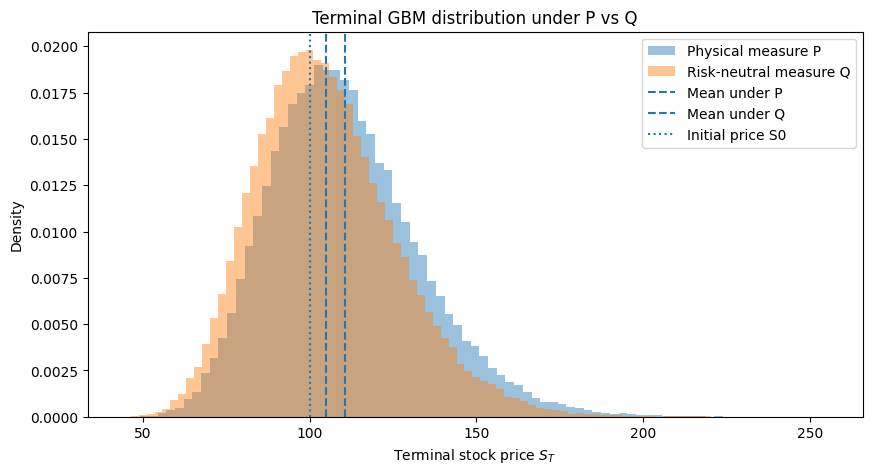

In [3]:
# ============================================================
# Cell 04 — Simulate terminal GBM under P and Q
# ============================================================

def measure_drift(cfg: BSMModelConfig, measure: MeasureType) -> float:
    """
    Return the GBM drift under the requested measure.

    Under P:
        drift = mu

    Under Q:
        drift = r - q
    """
    if measure == "P":
        return cfg.mu

    if measure == "Q":
        return cfg.r - cfg.q

    raise ValueError("measure must be either 'P' or 'Q'.")


def simulate_gbm_terminal(
    cfg: BSMModelConfig,
    n_paths: int,
    measure: MeasureType,
    seed: int,
) -> np.ndarray:
    """
    Simulate terminal GBM prices exactly.

    The exact terminal solution is:

        S_T = S_0 * exp((drift - 0.5 * sigma^2) * T + sigma * sqrt(T) * Z)

    where Z is standard normal.
    """
    if n_paths <= 0:
        raise ValueError("n_paths must be positive.")

    drift = measure_drift(cfg, measure)
    local_rng = np.random.default_rng(seed)

    z = local_rng.standard_normal(n_paths)

    terminal_prices = cfg.S0 * np.exp(
        (drift - 0.5 * cfg.sigma**2) * cfg.T
        + cfg.sigma * math.sqrt(cfg.T) * z
    )

    return terminal_prices


def summarize_terminal_distribution(
    terminal_prices: np.ndarray,
    cfg: BSMModelConfig,
    measure: MeasureType,
) -> dict[str, float | str]:
    """
    Summarize simulated terminal prices and compare their mean to the
    theoretical GBM terminal mean under the chosen measure.
    """
    drift = measure_drift(cfg, measure)
    theoretical_mean = cfg.S0 * math.exp(drift * cfg.T)

    sample_mean = float(np.mean(terminal_prices))
    sample_std = float(np.std(terminal_prices, ddof=1))
    sample_se = sample_std / math.sqrt(len(terminal_prices))

    return {
        "measure": measure,
        "drift_used": drift,
        "sample_mean_ST": sample_mean,
        "theoretical_mean_ST": theoretical_mean,
        "mean_error": sample_mean - theoretical_mean,
        "sample_std_ST": sample_std,
        "sample_se_mean": sample_se,
        "terminal_p05": float(np.quantile(terminal_prices, 0.05)),
        "terminal_p50": float(np.quantile(terminal_prices, 0.50)),
        "terminal_p95": float(np.quantile(terminal_prices, 0.95)),
    }


# ------------------------------------------------------------
# Simulate terminal prices under P and Q
# ------------------------------------------------------------

terminal_P = simulate_gbm_terminal(
    cfg=model_cfg,
    n_paths=sim_cfg.n_paths,
    measure="P",
    seed=sim_cfg.seed + 101,
)

terminal_Q = simulate_gbm_terminal(
    cfg=model_cfg,
    n_paths=sim_cfg.n_paths,
    measure="Q",
    seed=sim_cfg.seed + 202,
)

terminal_summary = pd.DataFrame(
    [
        summarize_terminal_distribution(terminal_P, model_cfg, "P"),
        summarize_terminal_distribution(terminal_Q, model_cfg, "Q"),
    ]
).set_index("measure")

print("Terminal GBM distribution under physical and risk-neutral measures")
display(terminal_summary)


# ------------------------------------------------------------
# Immediate interpretation table
# ------------------------------------------------------------

discounted_mean_P = math.exp(-model_cfg.r * model_cfg.T) * float(np.mean(terminal_P))
discounted_mean_Q = math.exp(-model_cfg.r * model_cfg.T) * float(np.mean(terminal_Q))

carry_adjusted_mean_Q = math.exp(-(model_cfg.r - model_cfg.q) * model_cfg.T) * float(np.mean(terminal_Q))

measure_interpretation = pd.DataFrame(
    {
        "value": {
            "E_P_ST_sample": float(np.mean(terminal_P)),
            "E_Q_ST_sample": float(np.mean(terminal_Q)),
            "discounted_E_P_ST": discounted_mean_P,
            "discounted_E_Q_ST": discounted_mean_Q,
            "carry_adjusted_E_Q_ST": carry_adjusted_mean_Q,
            "S0": model_cfg.S0,
        },
        "interpretation": {
            "E_P_ST_sample": "sample mean terminal stock price under physical drift mu",
            "E_Q_ST_sample": "sample mean terminal stock price under risk-neutral drift r - q",
            "discounted_E_P_ST": "exp(-rT) * E_P[S_T]; not required to equal S0",
            "discounted_E_Q_ST": "exp(-rT) * E_Q[S_T]; equals S0 only when q = 0",
            "carry_adjusted_E_Q_ST": "exp(-(r-q)T) * E_Q[S_T]; should be near S0",
            "S0": "initial stock price",
        },
    }
)

print("First martingale intuition check from terminal simulation")
display(measure_interpretation)

print(
    "Key contrast: P uses the real-world drift for forecasting, "
    "while Q uses the risk-neutral drift for no-arbitrage pricing."
)


# ------------------------------------------------------------
# Visualization: terminal distributions under P and Q
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    terminal_P,
    bins=80,
    alpha=0.45,
    density=True,
    label="Physical measure P",
)

ax.hist(
    terminal_Q,
    bins=80,
    alpha=0.45,
    density=True,
    label="Risk-neutral measure Q",
)

ax.axvline(np.mean(terminal_P), linestyle="--", linewidth=1.5, label="Mean under P")
ax.axvline(np.mean(terminal_Q), linestyle="--", linewidth=1.5, label="Mean under Q")
ax.axvline(model_cfg.S0, linestyle=":", linewidth=1.5, label="Initial price S0")

ax.set_title("Terminal GBM distribution under P vs Q")
ax.set_xlabel("Terminal stock price $S_T$")
ax.set_ylabel("Density")
ax.legend()

plt.show()

Martingale diagnostics across time


,time,E_P[S_t]_sample,E_P[S_t]_theory,disc_E_P[S_t],carry_adj_E_P[S_t],P_error_vs_S0,E_Q[S_t]_sample,E_Q[S_t]_theory,disc_E_Q[S_t],carry_adj_E_Q[S_t],Q_error_vs_S0
0,0.000000,100.000000,100.000000,100.000000,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,0.000000
1,0.250000,102.433691,102.531512,101.161239,101.161239,1.161239,101.297853,101.257845,100.039511,100.039511,0.039511
2,0.500000,104.996733,105.127110,102.404354,102.404354,2.404354,102.538409,102.531512,100.006726,100.006726,0.006726
3,0.750000,107.686021,107.788415,103.722575,103.722575,3.722575,103.746002,103.821200,99.927570,99.927570,-0.072430
4,1.000000,110.312896,110.517092,104.932873,104.932873,4.932873,105.095808,105.127110,99.970225,99.970225,-0.029775


Martingale check summary


,value,interpretation
martingale_n_paths,"50,000.000000",number of paths used for full-path martingale ...
max_abs_Q_error_vs_S0,0.072430,largest error of exp(-(r-q)t) E_Q[S_t] versus S0
max_abs_P_error_vs_S0,4.932873,largest error of exp(-(r-q)t) E_P[S_t] versus S0
mu_minus_r_minus_q,0.050000,drift gap separating physical and risk-neutral...


Risk-neutral martingale check: PASS


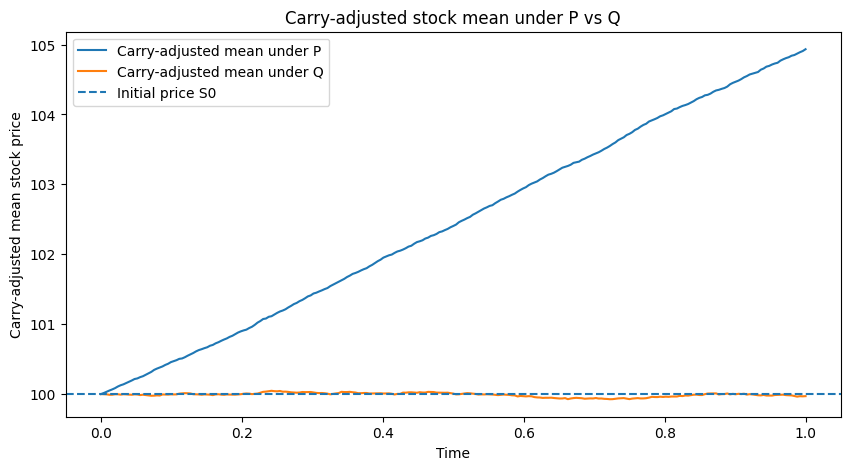

In [4]:
# ============================================================
# Cell 05 — Full-path GBM simulation and martingale diagnostics
# ============================================================

def simulate_gbm_paths(
    cfg: BSMModelConfig,
    n_paths: int,
    n_steps: int,
    measure: MeasureType,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Simulate full GBM paths exactly on a fixed time grid.

    For each step:

        S_{t+dt} = S_t * exp((drift - 0.5 sigma^2)dt + sigma sqrt(dt) Z)

    where drift is:
        P: mu
        Q: r - q

    Returns
    -------
    time_grid
        Shape: (n_steps + 1,)

    paths
        Shape: (n_paths, n_steps + 1)
    """
    if n_paths <= 0:
        raise ValueError("n_paths must be positive.")
    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")

    drift = measure_drift(cfg, measure)
    local_rng = np.random.default_rng(seed)

    time_grid = np.linspace(0.0, cfg.T, n_steps + 1)
    dt = cfg.T / n_steps

    z = local_rng.standard_normal((n_paths, n_steps))

    log_increments = (
        (drift - 0.5 * cfg.sigma**2) * dt
        + cfg.sigma * math.sqrt(dt) * z
    )

    log_paths = np.cumsum(log_increments, axis=1)
    log_paths = np.column_stack([np.zeros(n_paths), log_paths])

    paths = cfg.S0 * np.exp(log_paths)

    return time_grid, paths


def make_martingale_diagnostic_table(
    time_grid: np.ndarray,
    paths_P: np.ndarray,
    paths_Q: np.ndarray,
    cfg: BSMModelConfig,
    checkpoint_times: tuple[float, ...],
) -> pd.DataFrame:
    """
    Compare discounted and carry-adjusted sample means under P and Q.

    Under Q:

        E_Q[S_t] = S0 * exp((r - q)t)

    so:

        exp(-(r - q)t) * E_Q[S_t] = S0

    When q = 0, this is the usual discounted-stock martingale check:

        exp(-rt) * E_Q[S_t] = S0
    """
    rows = []

    for t in checkpoint_times:
        idx = int(np.argmin(np.abs(time_grid - t)))
        actual_t = float(time_grid[idx])

        mean_P = float(np.mean(paths_P[:, idx]))
        mean_Q = float(np.mean(paths_Q[:, idx]))

        discounted_mean_P = math.exp(-cfg.r * actual_t) * mean_P
        discounted_mean_Q = math.exp(-cfg.r * actual_t) * mean_Q

        carry_adjusted_mean_P = math.exp(-(cfg.r - cfg.q) * actual_t) * mean_P
        carry_adjusted_mean_Q = math.exp(-(cfg.r - cfg.q) * actual_t) * mean_Q

        theoretical_mean_P = cfg.S0 * math.exp(cfg.mu * actual_t)
        theoretical_mean_Q = cfg.S0 * math.exp((cfg.r - cfg.q) * actual_t)

        rows.append(
            {
                "time": actual_t,
                "E_P[S_t]_sample": mean_P,
                "E_P[S_t]_theory": theoretical_mean_P,
                "disc_E_P[S_t]": discounted_mean_P,
                "carry_adj_E_P[S_t]": carry_adjusted_mean_P,
                "P_error_vs_S0": carry_adjusted_mean_P - cfg.S0,
                "E_Q[S_t]_sample": mean_Q,
                "E_Q[S_t]_theory": theoretical_mean_Q,
                "disc_E_Q[S_t]": discounted_mean_Q,
                "carry_adj_E_Q[S_t]": carry_adjusted_mean_Q,
                "Q_error_vs_S0": carry_adjusted_mean_Q - cfg.S0,
            }
        )

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Simulate full paths for martingale diagnostics
# ------------------------------------------------------------

martingale_n_paths = min(50_000, sim_cfg.n_paths)

time_grid, paths_P = simulate_gbm_paths(
    cfg=model_cfg,
    n_paths=martingale_n_paths,
    n_steps=sim_cfg.n_steps,
    measure="P",
    seed=sim_cfg.seed + 303,
)

_, paths_Q = simulate_gbm_paths(
    cfg=model_cfg,
    n_paths=martingale_n_paths,
    n_steps=sim_cfg.n_steps,
    measure="Q",
    seed=sim_cfg.seed + 404,
)

checkpoint_times = (0.00, 0.25, 0.50, 0.75, 1.00)

martingale_table = make_martingale_diagnostic_table(
    time_grid=time_grid,
    paths_P=paths_P,
    paths_Q=paths_Q,
    cfg=model_cfg,
    checkpoint_times=checkpoint_times,
)

print("Martingale diagnostics across time")
display(martingale_table)


# ------------------------------------------------------------
# Summary checks
# ------------------------------------------------------------

max_abs_q_error = float(np.max(np.abs(martingale_table["Q_error_vs_S0"])))
max_abs_p_error = float(np.max(np.abs(martingale_table["P_error_vs_S0"])))

martingale_check_summary = pd.DataFrame(
    {
        "value": {
            "martingale_n_paths": martingale_n_paths,
            "max_abs_Q_error_vs_S0": max_abs_q_error,
            "max_abs_P_error_vs_S0": max_abs_p_error,
            "mu_minus_r_minus_q": model_cfg.mu - (model_cfg.r - model_cfg.q),
        },
        "interpretation": {
            "martingale_n_paths": "number of paths used for full-path martingale check",
            "max_abs_Q_error_vs_S0": "largest error of exp(-(r-q)t) E_Q[S_t] versus S0",
            "max_abs_P_error_vs_S0": "largest error of exp(-(r-q)t) E_P[S_t] versus S0",
            "mu_minus_r_minus_q": "drift gap separating physical and risk-neutral measures",
        },
    }
)

print("Martingale check summary")
display(martingale_check_summary)

if max_abs_q_error < 0.50:
    print("Risk-neutral martingale check: PASS")
else:
    print("Risk-neutral martingale check: REVIEW")


# ------------------------------------------------------------
# Visualization: carry-adjusted mean paths under P and Q
# ------------------------------------------------------------

mean_path_P = np.mean(paths_P, axis=0)
mean_path_Q = np.mean(paths_Q, axis=0)

carry_adjusted_mean_path_P = np.exp(-(model_cfg.r - model_cfg.q) * time_grid) * mean_path_P
carry_adjusted_mean_path_Q = np.exp(-(model_cfg.r - model_cfg.q) * time_grid) * mean_path_Q

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(time_grid, carry_adjusted_mean_path_P, label="Carry-adjusted mean under P")
ax.plot(time_grid, carry_adjusted_mean_path_Q, label="Carry-adjusted mean under Q")
ax.axhline(model_cfg.S0, linestyle="--", linewidth=1.5, label="Initial price S0")

ax.set_title("Carry-adjusted stock mean under P vs Q")
ax.set_xlabel("Time")
ax.set_ylabel("Carry-adjusted mean stock price")
ax.legend()

plt.show()

Risk-neutral Monte Carlo convergence against BSM benchmark


,option_type,n_paths,bsm_benchmark,mc_price_Q,standard_error,ci_95_lower,ci_95_upper,mc_minus_bsm,abs_error,ci_contains_bsm
0,call,1000,10.450584,10.529443,0.475154,9.598140,11.460746,0.078859,0.078859,True
1,put,1000,5.573526,5.943822,0.279949,5.395121,6.492522,0.370296,0.370296,True
2,call,5000,10.450584,10.499216,0.209997,10.087622,10.910809,0.048632,0.048632,True
3,put,5000,5.573526,5.447391,0.119589,5.212997,5.681785,-0.126135,0.126135,True
4,call,10000,10.450584,10.648536,0.149585,10.355349,10.941723,0.197952,0.197952,True
5,put,10000,5.573526,5.454866,0.085377,5.287528,5.622204,-0.118660,0.118660,True
6,call,50000,10.450584,10.369570,0.065817,10.240569,10.498572,-0.081013,0.081013,True
7,put,50000,5.573526,5.576717,0.038616,5.501029,5.652405,0.003191,0.003191,True
8,call,100000,10.450584,10.414127,0.046324,10.323332,10.504923,-0.036456,0.036456,True
9,put,100000,5.573526,5.581540,0.027490,5.527660,5.635421,0.008014,0.008014,True


Final risk-neutral Monte Carlo summary


,value,interpretation
final_call_abs_error,0.036456,absolute call pricing error at largest path count
final_put_abs_error,0.008014,absolute put pricing error at largest path count
final_call_standard_error,0.046324,call Monte Carlo standard error at largest pat...
final_put_standard_error,0.027490,put Monte Carlo standard error at largest path...
call_ci_contains_bsm,True,whether final call confidence interval contain...
put_ci_contains_bsm,True,whether final put confidence interval contains...


Risk-neutral Monte Carlo pricing check: PASS


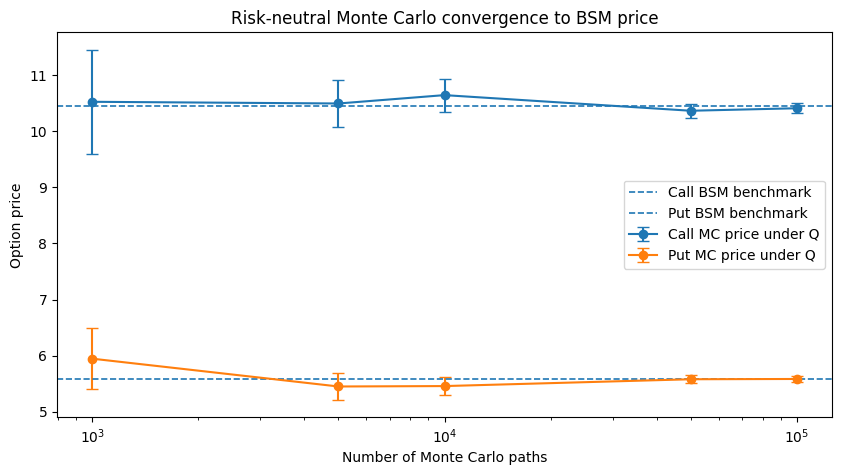

In [5]:
# ============================================================
# Cell 06 — Risk-neutral Monte Carlo pricing convergence
# ============================================================

def option_payoff(
    terminal_prices: np.ndarray,
    K: float,
    option_type: OptionType,
) -> np.ndarray:
    """
    European option payoff at maturity.
    """
    if option_type == "call":
        return np.maximum(terminal_prices - K, 0.0)

    if option_type == "put":
        return np.maximum(K - terminal_prices, 0.0)

    raise ValueError("option_type must be either 'call' or 'put'.")


def monte_carlo_option_price_from_terminal(
    terminal_prices: np.ndarray,
    cfg: BSMModelConfig,
    option_type: OptionType,
) -> dict[str, float]:
    """
    Estimate a European option price from simulated terminal stock prices.

    The Monte Carlo estimator is:

        exp(-rT) * mean(payoff(S_T))

    The standard error is computed from the discounted payoff sample.
    """
    payoff = option_payoff(
        terminal_prices=terminal_prices,
        K=cfg.K,
        option_type=option_type,
    )

    discounted_payoff = math.exp(-cfg.r * cfg.T) * payoff

    price_estimate = float(np.mean(discounted_payoff))
    sample_std = float(np.std(discounted_payoff, ddof=1))
    standard_error = sample_std / math.sqrt(len(discounted_payoff))

    ci_lower = price_estimate - 1.96 * standard_error
    ci_upper = price_estimate + 1.96 * standard_error

    return {
        "mc_price": price_estimate,
        "std_discounted_payoff": sample_std,
        "standard_error": standard_error,
        "ci_95_lower": ci_lower,
        "ci_95_upper": ci_upper,
    }


def run_risk_neutral_mc_convergence(
    cfg: BSMModelConfig,
    path_grid: tuple[int, ...],
    base_seed: int,
) -> pd.DataFrame:
    """
    Run Monte Carlo pricing under Q for increasing path counts.

    The benchmark is the closed-form Black-Scholes-Merton price.
    """
    rows = []

    for i, n_paths in enumerate(path_grid):
        terminal_prices_Q = simulate_gbm_terminal(
            cfg=cfg,
            n_paths=n_paths,
            measure="Q",
            seed=base_seed + 10_000 + i,
        )

        for option_type in ("call", "put"):
            mc_result = monte_carlo_option_price_from_terminal(
                terminal_prices=terminal_prices_Q,
                cfg=cfg,
                option_type=option_type,
            )

            benchmark = float(
                bsm_price(
                    S=cfg.S0,
                    K=cfg.K,
                    tau=cfg.T,
                    r=cfg.r,
                    q=cfg.q,
                    sigma=cfg.sigma,
                    option_type=option_type,
                )
            )

            abs_error = mc_result["mc_price"] - benchmark

            rows.append(
                {
                    "option_type": option_type,
                    "n_paths": n_paths,
                    "bsm_benchmark": benchmark,
                    "mc_price_Q": mc_result["mc_price"],
                    "standard_error": mc_result["standard_error"],
                    "ci_95_lower": mc_result["ci_95_lower"],
                    "ci_95_upper": mc_result["ci_95_upper"],
                    "mc_minus_bsm": abs_error,
                    "abs_error": abs(abs_error),
                    "ci_contains_bsm": (
                        mc_result["ci_95_lower"]
                        <= benchmark
                        <= mc_result["ci_95_upper"]
                    ),
                }
            )

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Run risk-neutral Monte Carlo convergence experiment
# ------------------------------------------------------------

mc_convergence = run_risk_neutral_mc_convergence(
    cfg=model_cfg,
    path_grid=sim_cfg.mc_path_grid,
    base_seed=sim_cfg.seed,
)

print("Risk-neutral Monte Carlo convergence against BSM benchmark")
display(mc_convergence)


# ------------------------------------------------------------
# Compact final-row summary
# ------------------------------------------------------------

final_mc_rows = (
    mc_convergence
    .sort_values(["option_type", "n_paths"])
    .groupby("option_type", as_index=False)
    .tail(1)
    .set_index("option_type")
)

mc_final_summary = pd.DataFrame(
    {
        "value": {
            "final_call_abs_error": float(final_mc_rows.loc["call", "abs_error"]),
            "final_put_abs_error": float(final_mc_rows.loc["put", "abs_error"]),
            "final_call_standard_error": float(final_mc_rows.loc["call", "standard_error"]),
            "final_put_standard_error": float(final_mc_rows.loc["put", "standard_error"]),
            "call_ci_contains_bsm": bool(final_mc_rows.loc["call", "ci_contains_bsm"]),
            "put_ci_contains_bsm": bool(final_mc_rows.loc["put", "ci_contains_bsm"]),
        },
        "interpretation": {
            "final_call_abs_error": "absolute call pricing error at largest path count",
            "final_put_abs_error": "absolute put pricing error at largest path count",
            "final_call_standard_error": "call Monte Carlo standard error at largest path count",
            "final_put_standard_error": "put Monte Carlo standard error at largest path count",
            "call_ci_contains_bsm": "whether final call confidence interval contains BSM benchmark",
            "put_ci_contains_bsm": "whether final put confidence interval contains BSM benchmark",
        },
    }
)

print("Final risk-neutral Monte Carlo summary")
display(mc_final_summary)

if (
    bool(final_mc_rows.loc["call", "ci_contains_bsm"])
    and bool(final_mc_rows.loc["put", "ci_contains_bsm"])
):
    print("Risk-neutral Monte Carlo pricing check: PASS")
else:
    print("Risk-neutral Monte Carlo pricing check: REVIEW")


# ------------------------------------------------------------
# Visualization: MC convergence toward BSM
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

for option_type in ("call", "put"):
    subset = mc_convergence[mc_convergence["option_type"] == option_type]

    ax.errorbar(
        subset["n_paths"],
        subset["mc_price_Q"],
        yerr=1.96 * subset["standard_error"],
        marker="o",
        capsize=4,
        label=f"{option_type.capitalize()} MC price under Q",
    )

    benchmark = float(
        bsm_price(
            S=model_cfg.S0,
            K=model_cfg.K,
            tau=model_cfg.T,
            r=model_cfg.r,
            q=model_cfg.q,
            sigma=model_cfg.sigma,
            option_type=option_type,
        )
    )

    ax.axhline(
        benchmark,
        linestyle="--",
        linewidth=1.2,
        label=f"{option_type.capitalize()} BSM benchmark",
    )

ax.set_xscale("log")
ax.set_title("Risk-neutral Monte Carlo convergence to BSM price")
ax.set_xlabel("Number of Monte Carlo paths")
ax.set_ylabel("Option price")
ax.legend()

plt.show()

Physical-drift Monte Carlo versus risk-neutral Monte Carlo


,option_type,bsm_benchmark,mc_price_Q,mc_price_P_discounted_payoff,se_Q,se_P,Q_minus_BSM,P_minus_BSM,P_minus_Q,mu_used_under_P,risk_neutral_drift_used_under_Q
0,call,10.450584,10.411356,13.909929,0.046230,0.053230,-0.039228,3.459345,3.498573,0.100000,0.050000
1,put,5.573526,5.583239,3.957211,0.027484,0.023394,0.009713,-1.616315,-1.626027,0.100000,0.050000


P-vs-Q interpretation summary


,value,interpretation
physical_drift_mu,0.100000,real-world expected return used under P
risk_neutral_drift_r_minus_q,0.050000,pricing drift used under Q
drift_gap,0.050000,positive gap means P distribution is shifted t...
call_P_minus_BSM,3.459345,physical discounted call payoff minus no-arbit...
put_P_minus_BSM,-1.616315,physical discounted put payoff minus no-arbitr...


Risk-neutral MC remains close to BSM: PASS
Physical-drift discounted payoff differs materially from BSM: PASS
Interpretation: discounted expected payoff under P is not the no-arbitrage price. The no-arbitrage price is obtained under Q because it is tied to replication.


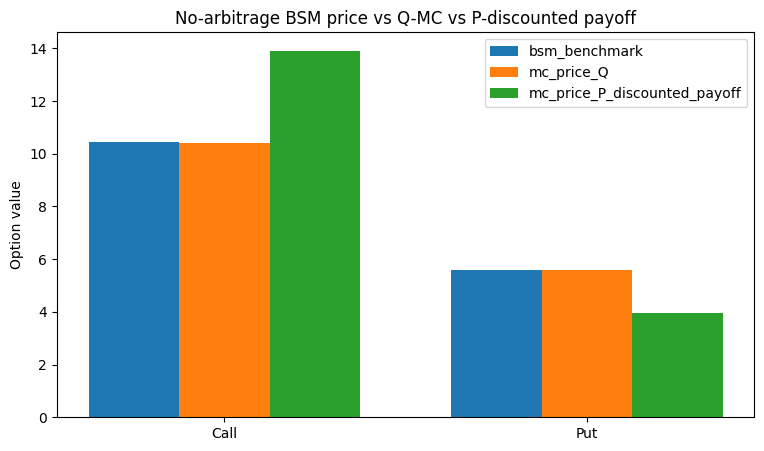

In [6]:
# ============================================================
# Cell 07 — Physical-drift Monte Carlo is not no-arbitrage pricing
# ============================================================

def simulate_terminal_pair_common_random_numbers(
    cfg: BSMModelConfig,
    n_paths: int,
    seed: int,
) -> pd.DataFrame:
    """
    Simulate terminal prices under P and Q using the same normal shocks.

    Using common random numbers makes the P-vs-Q comparison cleaner:
    the only systematic difference is the drift, not random sampling noise.
    """
    if n_paths <= 0:
        raise ValueError("n_paths must be positive.")

    local_rng = np.random.default_rng(seed)
    z = local_rng.standard_normal(n_paths)

    drift_P = measure_drift(cfg, "P")
    drift_Q = measure_drift(cfg, "Q")

    terminal_P_common = cfg.S0 * np.exp(
        (drift_P - 0.5 * cfg.sigma**2) * cfg.T
        + cfg.sigma * math.sqrt(cfg.T) * z
    )

    terminal_Q_common = cfg.S0 * np.exp(
        (drift_Q - 0.5 * cfg.sigma**2) * cfg.T
        + cfg.sigma * math.sqrt(cfg.T) * z
    )

    return pd.DataFrame(
        {
            "S_T_P": terminal_P_common,
            "S_T_Q": terminal_Q_common,
        }
    )


def compare_physical_vs_risk_neutral_mc(
    terminal_pair: pd.DataFrame,
    cfg: BSMModelConfig,
) -> pd.DataFrame:
    """
    Compare discounted expected payoffs under P and Q.

    The Q estimator is a no-arbitrage Monte Carlo price.

    The P estimator is a discounted physical expected payoff. It may be useful
    for forecasting expected realized payoff, but it is not the replication price.
    """
    rows = []

    for option_type in ("call", "put"):
        payoff_P = option_payoff(
            terminal_prices=terminal_pair["S_T_P"].to_numpy(),
            K=cfg.K,
            option_type=option_type,
        )

        payoff_Q = option_payoff(
            terminal_prices=terminal_pair["S_T_Q"].to_numpy(),
            K=cfg.K,
            option_type=option_type,
        )

        discounted_payoff_P = math.exp(-cfg.r * cfg.T) * payoff_P
        discounted_payoff_Q = math.exp(-cfg.r * cfg.T) * payoff_Q

        price_P = float(np.mean(discounted_payoff_P))
        price_Q = float(np.mean(discounted_payoff_Q))

        se_P = float(np.std(discounted_payoff_P, ddof=1) / math.sqrt(len(discounted_payoff_P)))
        se_Q = float(np.std(discounted_payoff_Q, ddof=1) / math.sqrt(len(discounted_payoff_Q)))

        bsm = float(
            bsm_price(
                S=cfg.S0,
                K=cfg.K,
                tau=cfg.T,
                r=cfg.r,
                q=cfg.q,
                sigma=cfg.sigma,
                option_type=option_type,
            )
        )

        rows.append(
            {
                "option_type": option_type,
                "bsm_benchmark": bsm,
                "mc_price_Q": price_Q,
                "mc_price_P_discounted_payoff": price_P,
                "se_Q": se_Q,
                "se_P": se_P,
                "Q_minus_BSM": price_Q - bsm,
                "P_minus_BSM": price_P - bsm,
                "P_minus_Q": price_P - price_Q,
                "mu_used_under_P": cfg.mu,
                "risk_neutral_drift_used_under_Q": cfg.r - cfg.q,
            }
        )

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Run P-vs-Q Monte Carlo comparison with common random shocks
# ------------------------------------------------------------

terminal_pair = simulate_terminal_pair_common_random_numbers(
    cfg=model_cfg,
    n_paths=sim_cfg.n_paths,
    seed=sim_cfg.seed + 505,
)

pq_price_comparison = compare_physical_vs_risk_neutral_mc(
    terminal_pair=terminal_pair,
    cfg=model_cfg,
)

print("Physical-drift Monte Carlo versus risk-neutral Monte Carlo")
display(pq_price_comparison)


# ------------------------------------------------------------
# Interpretation summary
# ------------------------------------------------------------

pq_interpretation = pd.DataFrame(
    {
        "value": {
            "physical_drift_mu": model_cfg.mu,
            "risk_neutral_drift_r_minus_q": model_cfg.r - model_cfg.q,
            "drift_gap": model_cfg.mu - (model_cfg.r - model_cfg.q),
            "call_P_minus_BSM": float(
                pq_price_comparison.loc[
                    pq_price_comparison["option_type"] == "call",
                    "P_minus_BSM",
                ].iloc[0]
            ),
            "put_P_minus_BSM": float(
                pq_price_comparison.loc[
                    pq_price_comparison["option_type"] == "put",
                    "P_minus_BSM",
                ].iloc[0]
            ),
        },
        "interpretation": {
            "physical_drift_mu": "real-world expected return used under P",
            "risk_neutral_drift_r_minus_q": "pricing drift used under Q",
            "drift_gap": "positive gap means P distribution is shifted to the right",
            "call_P_minus_BSM": "physical discounted call payoff minus no-arbitrage call price",
            "put_P_minus_BSM": "physical discounted put payoff minus no-arbitrage put price",
        },
    }
)

print("P-vs-Q interpretation summary")
display(pq_interpretation)


# ------------------------------------------------------------
# Validation logic
# ------------------------------------------------------------

max_abs_q_bsm_error = float(np.max(np.abs(pq_price_comparison["Q_minus_BSM"])))
min_abs_p_bsm_gap = float(np.min(np.abs(pq_price_comparison["P_minus_BSM"])))

if max_abs_q_bsm_error < 3.0 * float(np.max(pq_price_comparison["se_Q"])):
    print("Risk-neutral MC remains close to BSM: PASS")
else:
    print("Risk-neutral MC remains close to BSM: REVIEW")

if min_abs_p_bsm_gap > 3.0 * float(np.max(pq_price_comparison["se_P"])):
    print("Physical-drift discounted payoff differs materially from BSM: PASS")
else:
    print("Physical-drift discounted payoff differs materially from BSM: REVIEW")

print(
    "Interpretation: discounted expected payoff under P is not the no-arbitrage price. "
    "The no-arbitrage price is obtained under Q because it is tied to replication."
)


# ------------------------------------------------------------
# Visualization: BSM vs Q-MC vs P-discounted payoff
# ------------------------------------------------------------

plot_df = pq_price_comparison.melt(
    id_vars="option_type",
    value_vars=[
        "bsm_benchmark",
        "mc_price_Q",
        "mc_price_P_discounted_payoff",
    ],
    var_name="method",
    value_name="price",
)

fig, ax = plt.subplots(figsize=(9, 5))

option_labels = ["call", "put"]
method_labels = [
    "bsm_benchmark",
    "mc_price_Q",
    "mc_price_P_discounted_payoff",
]

x = np.arange(len(option_labels))
bar_width = 0.25

for j, method in enumerate(method_labels):
    values = [
        float(
            plot_df[
                (plot_df["option_type"] == option_type)
                & (plot_df["method"] == method)
            ]["price"].iloc[0]
        )
        for option_type in option_labels
    ]

    ax.bar(
        x + (j - 1) * bar_width,
        values,
        width=bar_width,
        label=method,
    )

ax.set_xticks(x)
ax.set_xticklabels([label.capitalize() for label in option_labels])
ax.set_title("No-arbitrage BSM price vs Q-MC vs P-discounted payoff")
ax.set_ylabel("Option value")
ax.legend()

plt.show()

Plain Monte Carlo versus antithetic Monte Carlo


,option_type,n_terminal_evaluations,method,bsm_benchmark,mc_price,standard_error,mc_minus_bsm,abs_error
0,call,1000,antithetic,10.450584,10.779434,0.329223,0.328850,0.328850
1,call,1000,plain,10.450584,10.546343,0.457996,0.095759,0.095759
2,call,5000,antithetic,10.450584,10.480514,0.144035,0.029930,0.029930
3,call,5000,plain,10.450584,10.439928,0.202241,-0.010656,0.010656
4,call,10000,antithetic,10.450584,10.264970,0.102420,-0.185614,0.185614
5,call,10000,plain,10.450584,10.535558,0.147564,0.084975,0.084975
6,call,50000,antithetic,10.450584,10.491766,0.046468,0.041183,0.041183
7,call,50000,plain,10.450584,10.382501,0.065373,-0.068083,0.068083
8,call,100000,antithetic,10.450584,10.461791,0.032842,0.011207,0.011207
9,call,100000,plain,10.450584,10.410632,0.046498,-0.039952,0.039952


Antithetic standard-error reduction summary


,option_type,n_terminal_evaluations,plain_standard_error,antithetic_standard_error,se_reduction,se_reduction_pct,antithetic_improved
0,call,1000,0.457996,0.329223,0.128773,28.116641,True
1,call,5000,0.202241,0.144035,0.058206,28.780396,True
2,call,10000,0.147564,0.102420,0.045143,30.592407,True
3,call,50000,0.065373,0.046468,0.018905,28.918882,True
4,call,100000,0.046498,0.032842,0.013656,29.368879,True
5,put,1000,0.280352,0.209971,0.070380,25.104311,True
6,put,5000,0.121531,0.093066,0.028466,23.422521,True
7,put,10000,0.085212,0.065467,0.019745,23.171276,True
8,put,50000,0.038716,0.029685,0.009032,23.327904,True
9,put,100000,0.027367,0.020940,0.006427,23.485571,True


Variance-reduction final summary


,value,interpretation
final_call_plain_se,0.046498,plain call MC standard error at largest path c...
final_call_antithetic_se,0.032842,antithetic call MC standard error at largest p...
final_call_se_reduction_pct,29.368879,percentage standard-error reduction for call
final_put_plain_se,0.027367,plain put MC standard error at largest path count
final_put_antithetic_se,0.020940,antithetic put MC standard error at largest pa...
final_put_se_reduction_pct,23.485571,percentage standard-error reduction for put


Antithetic variance-reduction check: PASS
Interpretation: antithetic variates do not change the pricing measure. They only try to estimate the same Q-expectation more efficiently.


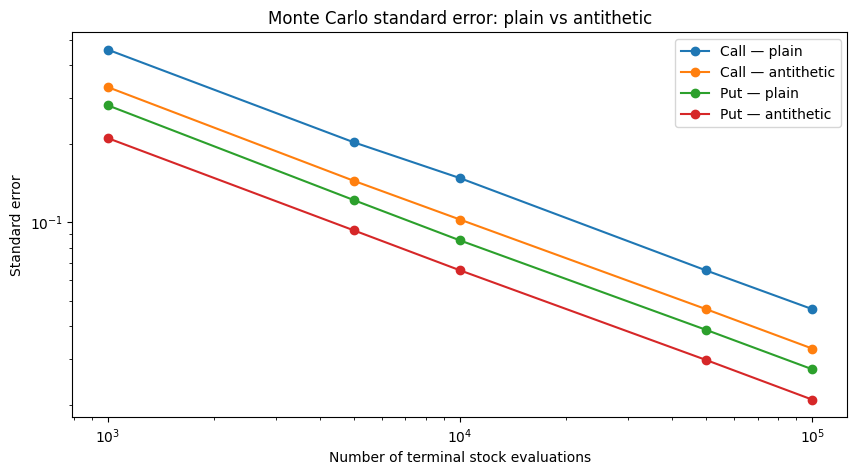

In [7]:
# ============================================================
# Cell 08 — Antithetic variates for risk-neutral Monte Carlo
# ============================================================

def gbm_terminal_from_standard_normals(
    cfg: BSMModelConfig,
    z: np.ndarray,
    measure: MeasureType,
) -> np.ndarray:
    """
    Convert standard normal shocks into exact terminal GBM prices.

    This function is useful for variance-reduction methods because it lets us
    control the random shocks directly.
    """
    drift = measure_drift(cfg, measure)

    terminal_prices = cfg.S0 * np.exp(
        (drift - 0.5 * cfg.sigma**2) * cfg.T
        + cfg.sigma * math.sqrt(cfg.T) * z
    )

    return terminal_prices


def plain_mc_from_normals(
    cfg: BSMModelConfig,
    z: np.ndarray,
    option_type: OptionType,
) -> dict[str, float]:
    """
    Plain Monte Carlo estimator using supplied standard normal shocks.
    """
    terminal_prices = gbm_terminal_from_standard_normals(
        cfg=cfg,
        z=z,
        measure="Q",
    )

    payoff = option_payoff(
        terminal_prices=terminal_prices,
        K=cfg.K,
        option_type=option_type,
    )

    discounted_payoff = math.exp(-cfg.r * cfg.T) * payoff

    price = float(np.mean(discounted_payoff))
    standard_error = float(np.std(discounted_payoff, ddof=1) / math.sqrt(len(discounted_payoff)))

    return {
        "price": price,
        "standard_error": standard_error,
        "n_terminal_evaluations": int(len(discounted_payoff)),
    }


def antithetic_mc_from_normals(
    cfg: BSMModelConfig,
    z_pairs: np.ndarray,
    option_type: OptionType,
) -> dict[str, float]:
    """
    Antithetic Monte Carlo estimator.

    For each shock Z, also use -Z. The pair estimator is:

        0.5 * [payoff(S_T(Z)) + payoff(S_T(-Z))]

    The standard error is computed from the pair-average discounted payoffs,
    not from the 2N individual payoffs. This correctly accounts for the
    dependence inside each antithetic pair.
    """
    terminal_plus = gbm_terminal_from_standard_normals(
        cfg=cfg,
        z=z_pairs,
        measure="Q",
    )

    terminal_minus = gbm_terminal_from_standard_normals(
        cfg=cfg,
        z=-z_pairs,
        measure="Q",
    )

    payoff_plus = option_payoff(
        terminal_prices=terminal_plus,
        K=cfg.K,
        option_type=option_type,
    )

    payoff_minus = option_payoff(
        terminal_prices=terminal_minus,
        K=cfg.K,
        option_type=option_type,
    )

    discounted_pair_average = (
        math.exp(-cfg.r * cfg.T)
        * 0.5
        * (payoff_plus + payoff_minus)
    )

    price = float(np.mean(discounted_pair_average))
    standard_error = float(
        np.std(discounted_pair_average, ddof=1) / math.sqrt(len(discounted_pair_average))
    )

    return {
        "price": price,
        "standard_error": standard_error,
        "n_pairs": int(len(z_pairs)),
        "n_terminal_evaluations": int(2 * len(z_pairs)),
    }


def run_antithetic_variance_reduction_check(
    cfg: BSMModelConfig,
    path_grid: tuple[int, ...],
    base_seed: int,
) -> pd.DataFrame:
    """
    Compare plain Monte Carlo and antithetic Monte Carlo using the same
    total number of terminal stock evaluations.

    For antithetic MC, total terminal evaluations must be even because each
    shock Z is paired with -Z.
    """
    rows = []

    for i, n_total in enumerate(path_grid):
        if n_total < 2:
            continue

        if n_total % 2 != 0:
            n_total = n_total - 1

        n_pairs = n_total // 2

        local_rng = np.random.default_rng(base_seed + 20_000 + i)

        z_plain = local_rng.standard_normal(n_total)
        z_pairs = local_rng.standard_normal(n_pairs)

        for option_type in ("call", "put"):
            plain = plain_mc_from_normals(
                cfg=cfg,
                z=z_plain,
                option_type=option_type,
            )

            anti = antithetic_mc_from_normals(
                cfg=cfg,
                z_pairs=z_pairs,
                option_type=option_type,
            )

            benchmark = float(
                bsm_price(
                    S=cfg.S0,
                    K=cfg.K,
                    tau=cfg.T,
                    r=cfg.r,
                    q=cfg.q,
                    sigma=cfg.sigma,
                    option_type=option_type,
                )
            )

            rows.append(
                {
                    "option_type": option_type,
                    "n_terminal_evaluations": n_total,
                    "method": "plain",
                    "bsm_benchmark": benchmark,
                    "mc_price": plain["price"],
                    "standard_error": plain["standard_error"],
                    "mc_minus_bsm": plain["price"] - benchmark,
                    "abs_error": abs(plain["price"] - benchmark),
                }
            )

            rows.append(
                {
                    "option_type": option_type,
                    "n_terminal_evaluations": n_total,
                    "method": "antithetic",
                    "bsm_benchmark": benchmark,
                    "mc_price": anti["price"],
                    "standard_error": anti["standard_error"],
                    "mc_minus_bsm": anti["price"] - benchmark,
                    "abs_error": abs(anti["price"] - benchmark),
                }
            )

    result = pd.DataFrame(rows)

    return result.sort_values(
        ["option_type", "n_terminal_evaluations", "method"]
    ).reset_index(drop=True)


# ------------------------------------------------------------
# Run antithetic variance-reduction check
# ------------------------------------------------------------

variance_reduction_table = run_antithetic_variance_reduction_check(
    cfg=model_cfg,
    path_grid=sim_cfg.mc_path_grid,
    base_seed=sim_cfg.seed,
)

print("Plain Monte Carlo versus antithetic Monte Carlo")
display(variance_reduction_table)


# ------------------------------------------------------------
# Standard-error reduction summary
# ------------------------------------------------------------

se_comparison_rows = []

for option_type in ("call", "put"):
    for n_total in sorted(variance_reduction_table["n_terminal_evaluations"].unique()):
        subset = variance_reduction_table[
            (variance_reduction_table["option_type"] == option_type)
            & (variance_reduction_table["n_terminal_evaluations"] == n_total)
        ]

        plain_se = float(subset.loc[subset["method"] == "plain", "standard_error"].iloc[0])
        anti_se = float(subset.loc[subset["method"] == "antithetic", "standard_error"].iloc[0])

        se_comparison_rows.append(
            {
                "option_type": option_type,
                "n_terminal_evaluations": n_total,
                "plain_standard_error": plain_se,
                "antithetic_standard_error": anti_se,
                "se_reduction": plain_se - anti_se,
                "se_reduction_pct": 100.0 * (plain_se - anti_se) / plain_se,
                "antithetic_improved": anti_se <= plain_se,
            }
        )

se_comparison = pd.DataFrame(se_comparison_rows)

print("Antithetic standard-error reduction summary")
display(se_comparison)


# ------------------------------------------------------------
# Compact final-path summary
# ------------------------------------------------------------

final_se_comparison = (
    se_comparison
    .sort_values(["option_type", "n_terminal_evaluations"])
    .groupby("option_type", as_index=False)
    .tail(1)
    .set_index("option_type")
)

variance_reduction_summary = pd.DataFrame(
    {
        "value": {
            "final_call_plain_se": float(final_se_comparison.loc["call", "plain_standard_error"]),
            "final_call_antithetic_se": float(final_se_comparison.loc["call", "antithetic_standard_error"]),
            "final_call_se_reduction_pct": float(final_se_comparison.loc["call", "se_reduction_pct"]),
            "final_put_plain_se": float(final_se_comparison.loc["put", "plain_standard_error"]),
            "final_put_antithetic_se": float(final_se_comparison.loc["put", "antithetic_standard_error"]),
            "final_put_se_reduction_pct": float(final_se_comparison.loc["put", "se_reduction_pct"]),
        },
        "interpretation": {
            "final_call_plain_se": "plain call MC standard error at largest path count",
            "final_call_antithetic_se": "antithetic call MC standard error at largest path count",
            "final_call_se_reduction_pct": "percentage standard-error reduction for call",
            "final_put_plain_se": "plain put MC standard error at largest path count",
            "final_put_antithetic_se": "antithetic put MC standard error at largest path count",
            "final_put_se_reduction_pct": "percentage standard-error reduction for put",
        },
    }
)

print("Variance-reduction final summary")
display(variance_reduction_summary)

if bool(se_comparison["antithetic_improved"].all()):
    print("Antithetic variance-reduction check: PASS")
else:
    print("Antithetic variance-reduction check: REVIEW")

print(
    "Interpretation: antithetic variates do not change the pricing measure. "
    "They only try to estimate the same Q-expectation more efficiently."
)


# ------------------------------------------------------------
# Visualization: standard error by method
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

for option_type in ("call", "put"):
    for method in ("plain", "antithetic"):
        subset = variance_reduction_table[
            (variance_reduction_table["option_type"] == option_type)
            & (variance_reduction_table["method"] == method)
        ]

        ax.plot(
            subset["n_terminal_evaluations"],
            subset["standard_error"],
            marker="o",
            label=f"{option_type.capitalize()} — {method}",
        )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Monte Carlo standard error: plain vs antithetic")
ax.set_xlabel("Number of terminal stock evaluations")
ax.set_ylabel("Standard error")
ax.legend()

plt.show()

Single-path discrete delta hedge checkpoints


,step,time,tau,stock_price,option_value,delta_held,stock_position,cash_account,hedge_assets,net_mtm,payoff_at_maturity,terminal_pnl
0,0,0.000000,1.000000,100.000000,10.450584,0.636831,63.683065,-53.232482,10.450584,0.000000,NaN,NaN
13,13,0.250000,0.750000,95.821103,6.383851,0.522590,50.075109,-43.437415,6.637695,0.253844,NaN,NaN
26,26,0.500000,0.500000,107.489481,12.068681,0.775828,83.393383,-71.064043,12.329340,0.260659,NaN,NaN
39,39,0.750000,0.250000,111.339471,13.170528,0.894192,99.558909,-85.511950,14.046959,0.876431,NaN,NaN
52,52,1.000000,0.000000,105.567301,5.567301,0.992828,104.810140,-99.695700,5.114441,-0.452860,5.567301,-0.452860


Single-path hedge summary


,value,interpretation
option_type,call,short option being hedged
rebalance_steps,52,number of hedge rebalances over one year
initial_stock,100.000000,starting stock price
initial_option_premium,10.450584,premium received from selling the option
initial_delta,0.636831,shares bought to hedge the short option at inc...
initial_cash_account,-53.232482,cash after buying the initial stock hedge
terminal_stock,105.567301,stock price at maturity
terminal_payoff,5.567301,option liability paid at maturity
terminal_hedge_assets,5.114441,stock hedge plus cash account at maturity
terminal_pnl,-0.452860,discrete hedging error for this one path


Interpretation: the initial net mark-to-market value is zero by construction. The terminal P&L is not forced to be zero because the hedge is rebalanced discretely.


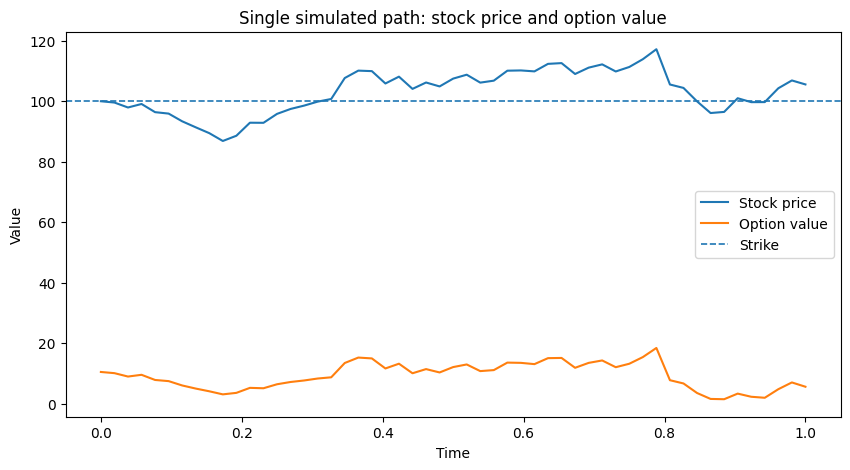

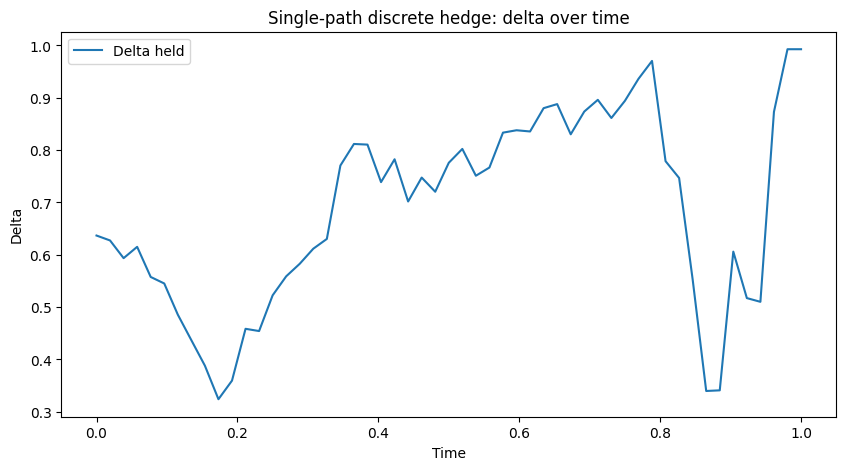

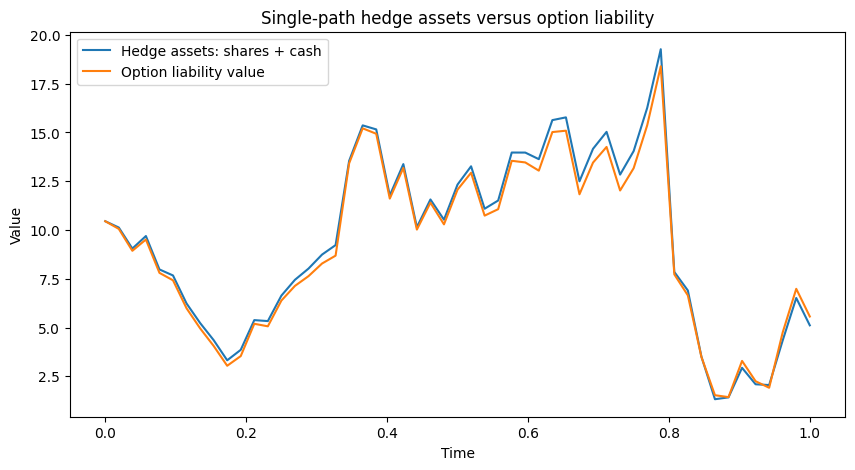

In [8]:
# ============================================================
# Cell 09 — Single-path discrete delta-hedging mechanics
# ============================================================

def simulate_single_gbm_path(
    cfg: BSMModelConfig,
    n_steps: int,
    measure: MeasureType,
    seed: int,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Simulate one exact-discretized GBM path on a fixed grid.

    This is used for a transparent single-path hedge demonstration before
    running many-path hedging-error experiments.
    """
    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")

    drift = measure_drift(cfg, measure)
    local_rng = np.random.default_rng(seed)

    time_grid = np.linspace(0.0, cfg.T, n_steps + 1)
    dt = cfg.T / n_steps

    z = local_rng.standard_normal(n_steps)

    log_increments = (
        (drift - 0.5 * cfg.sigma**2) * dt
        + cfg.sigma * math.sqrt(dt) * z
    )

    log_path = np.concatenate([[0.0], np.cumsum(log_increments)])
    stock_path = cfg.S0 * np.exp(log_path)

    return time_grid, stock_path


def run_single_path_delta_hedge(
    time_grid: np.ndarray,
    stock_path: np.ndarray,
    cfg: BSMModelConfig,
    option_type: OptionType = "call",
    hedge_sigma: float | None = None,
) -> pd.DataFrame:
    """
    Run a self-financing discrete delta hedge for one short option position.

    Sign convention
    ---------------
    The hedger sells one option at t = 0, receives the option premium, and
    hedges the short option liability by holding the Black-Scholes delta in
    shares.

    Initial cash account:

        cash_0 = option_premium - delta_0 * S_0

    Hedge portfolio before paying the liability:

        hedge_assets_t = delta_t * S_t + cash_t

    Mark-to-market net value:

        net_mtm_t = hedge_assets_t - option_value_t

    At maturity, option_value_t equals payoff, so:

        terminal_pnl = hedge_assets_T - payoff_T

    If hedging were continuous under exact BSM assumptions, terminal_pnl would
    be zero. With discrete rebalancing, it is generally not zero.
    """
    if option_type not in {"call", "put"}:
        raise ValueError("option_type must be either 'call' or 'put'.")

    if abs(cfg.q) > 1e-14:
        raise NotImplementedError(
            "This discrete hedge demonstration assumes q = 0. "
            "A nonzero dividend yield requires explicit dividend cash-flow bookkeeping."
        )

    if len(time_grid) != len(stock_path):
        raise ValueError("time_grid and stock_path must have the same length.")

    if len(time_grid) < 2:
        raise ValueError("time_grid must contain at least two points.")

    if not np.all(np.diff(time_grid) > 0):
        raise ValueError("time_grid must be strictly increasing.")

    hedge_sigma = cfg.sigma if hedge_sigma is None else hedge_sigma

    if hedge_sigma <= 0:
        raise ValueError("hedge_sigma must be strictly positive.")

    n_steps = len(time_grid) - 1

    initial_option_value = float(
        bsm_price(
            S=stock_path[0],
            K=cfg.K,
            tau=cfg.T,
            r=cfg.r,
            q=cfg.q,
            sigma=hedge_sigma,
            option_type=option_type,
        )
    )

    delta = float(
        bsm_delta(
            S=stock_path[0],
            K=cfg.K,
            tau=cfg.T,
            r=cfg.r,
            q=cfg.q,
            sigma=hedge_sigma,
            option_type=option_type,
        )
    )

    cash = initial_option_value - delta * stock_path[0]

    rows = []

    for i in range(n_steps + 1):
        t = float(time_grid[i])
        S_t = float(stock_path[i])
        tau = max(cfg.T - t, 0.0)

        if i > 0:
            dt = float(time_grid[i] - time_grid[i - 1])

            # Cash account accrues at the risk-free rate between hedge dates.
            cash *= math.exp(cfg.r * dt)

            # Rebalance only before maturity. At maturity, the previous hedge is liquidated
            # against the option payoff; there is no new hedge to set.
            if i < n_steps:
                new_delta = float(
                    bsm_delta(
                        S=S_t,
                        K=cfg.K,
                        tau=tau,
                        r=cfg.r,
                        q=cfg.q,
                        sigma=hedge_sigma,
                        option_type=option_type,
                    )
                )

                cash -= (new_delta - delta) * S_t
                delta = new_delta

        option_value = float(
            bsm_price(
                S=S_t,
                K=cfg.K,
                tau=tau,
                r=cfg.r,
                q=cfg.q,
                sigma=hedge_sigma,
                option_type=option_type,
            )
        )

        payoff = float(
            option_payoff(
                terminal_prices=np.array([S_t]),
                K=cfg.K,
                option_type=option_type,
            )[0]
        ) if i == n_steps else np.nan

        stock_position = delta * S_t
        hedge_assets = stock_position + cash
        net_mtm = hedge_assets - option_value
        terminal_pnl = hedge_assets - payoff if i == n_steps else np.nan

        rows.append(
            {
                "step": i,
                "time": t,
                "tau": tau,
                "stock_price": S_t,
                "option_value": option_value,
                "delta_held": delta,
                "stock_position": stock_position,
                "cash_account": cash,
                "hedge_assets": hedge_assets,
                "net_mtm": net_mtm,
                "payoff_at_maturity": payoff,
                "terminal_pnl": terminal_pnl,
            }
        )

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Run one transparent hedge path
# ------------------------------------------------------------

single_path_steps = 52

single_time_grid, single_stock_path = simulate_single_gbm_path(
    cfg=model_cfg,
    n_steps=single_path_steps,
    measure="Q",
    seed=sim_cfg.seed + 606,
)

single_hedge_ledger = run_single_path_delta_hedge(
    time_grid=single_time_grid,
    stock_path=single_stock_path,
    cfg=model_cfg,
    option_type="call",
    hedge_sigma=model_cfg.sigma,
)

checkpoint_steps = sorted(
    set(
        [
            0,
            single_path_steps // 4,
            single_path_steps // 2,
            3 * single_path_steps // 4,
            single_path_steps,
        ]
    )
)

single_hedge_checkpoints = single_hedge_ledger[
    single_hedge_ledger["step"].isin(checkpoint_steps)
].copy()

print("Single-path discrete delta hedge checkpoints")
display(single_hedge_checkpoints)


# ------------------------------------------------------------
# Single-path hedge summary
# ------------------------------------------------------------

terminal_row = single_hedge_ledger.iloc[-1]

single_hedge_summary = pd.DataFrame(
    {
        "value": {
            "option_type": "call",
            "rebalance_steps": single_path_steps,
            "initial_stock": float(single_hedge_ledger.iloc[0]["stock_price"]),
            "initial_option_premium": float(single_hedge_ledger.iloc[0]["option_value"]),
            "initial_delta": float(single_hedge_ledger.iloc[0]["delta_held"]),
            "initial_cash_account": float(single_hedge_ledger.iloc[0]["cash_account"]),
            "terminal_stock": float(terminal_row["stock_price"]),
            "terminal_payoff": float(terminal_row["payoff_at_maturity"]),
            "terminal_hedge_assets": float(terminal_row["hedge_assets"]),
            "terminal_pnl": float(terminal_row["terminal_pnl"]),
        },
        "interpretation": {
            "option_type": "short option being hedged",
            "rebalance_steps": "number of hedge rebalances over one year",
            "initial_stock": "starting stock price",
            "initial_option_premium": "premium received from selling the option",
            "initial_delta": "shares bought to hedge the short option at inception",
            "initial_cash_account": "cash after buying the initial stock hedge",
            "terminal_stock": "stock price at maturity",
            "terminal_payoff": "option liability paid at maturity",
            "terminal_hedge_assets": "stock hedge plus cash account at maturity",
            "terminal_pnl": "discrete hedging error for this one path",
        },
    }
)

print("Single-path hedge summary")
display(single_hedge_summary)

print(
    "Interpretation: the initial net mark-to-market value is zero by construction. "
    "The terminal P&L is not forced to be zero because the hedge is rebalanced discretely."
)


# ------------------------------------------------------------
# Visualization 1: stock path and option value
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    single_hedge_ledger["time"],
    single_hedge_ledger["stock_price"],
    label="Stock price",
)

ax.plot(
    single_hedge_ledger["time"],
    single_hedge_ledger["option_value"],
    label="Option value",
)

ax.axhline(model_cfg.K, linestyle="--", linewidth=1.2, label="Strike")

ax.set_title("Single simulated path: stock price and option value")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()

plt.show()


# ------------------------------------------------------------
# Visualization 2: hedge mechanics
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    single_hedge_ledger["time"],
    single_hedge_ledger["delta_held"],
    label="Delta held",
)

ax.set_title("Single-path discrete hedge: delta over time")
ax.set_xlabel("Time")
ax.set_ylabel("Delta")
ax.legend()

plt.show()


# ------------------------------------------------------------
# Visualization 3: hedge assets versus option liability
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    single_hedge_ledger["time"],
    single_hedge_ledger["hedge_assets"],
    label="Hedge assets: shares + cash",
)

ax.plot(
    single_hedge_ledger["time"],
    single_hedge_ledger["option_value"],
    label="Option liability value",
)

ax.set_title("Single-path hedge assets versus option liability")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend()

plt.show()

Discrete delta-hedging error by rebalancing frequency


,option_type,n_steps,n_paths,dt,hedge_sigma,true_sigma,mean_pnl,std_pnl,rmse_pnl,mean_abs_pnl,median_pnl,p01_pnl,p05_pnl,p95_pnl,p99_pnl
0,call,12,20000,0.083333,0.200000,0.200000,-0.013658,1.926677,1.926678,1.450812,0.019098,-5.438149,-3.192101,3.123005,4.573104
1,call,26,20000,0.038462,0.200000,0.200000,0.004524,1.321884,1.321858,0.996970,0.021465,-3.680503,-2.200629,2.148330,3.140731
2,call,52,20000,0.019231,0.200000,0.200000,0.000722,0.945979,0.945956,0.708095,0.009569,-2.562321,-1.556144,1.538660,2.392223
3,call,126,20000,0.007937,0.200000,0.200000,-0.000864,0.618060,0.618045,0.461853,0.004166,-1.656581,-1.013927,1.003600,1.617670
4,call,252,20000,0.003968,0.200000,0.200000,0.006590,0.433597,0.433636,0.323426,0.009119,-1.147391,-0.696834,0.704522,1.142005
5,call,504,20000,0.001984,0.200000,0.200000,-0.001170,0.308467,0.308461,0.230155,0.000829,-0.819927,-0.505191,0.494225,0.799855


Hedging-error convergence summary


,value,interpretation
lowest_frequency_steps,12.000000,coarsest hedge grid
highest_frequency_steps,504.000000,finest hedge grid
lowest_frequency_rmse,1.926678,hedging-error RMSE at coarsest hedge grid
highest_frequency_rmse,0.308461,hedging-error RMSE at finest hedge grid
rmse_change,-1.618216,negative means hedging RMSE declined
rmse_reduction_pct,83.989985,percentage decline in hedging-error RMSE
lowest_frequency_std,1.926677,P&L standard deviation at coarsest hedge grid
highest_frequency_std,0.308467,P&L standard deviation at finest hedge grid


Discrete hedging convergence check: PASS
Interpretation: under the correct BSM model, discrete hedging error should shrink as rebalancing becomes more frequent, but it does not vanish at finite frequency.


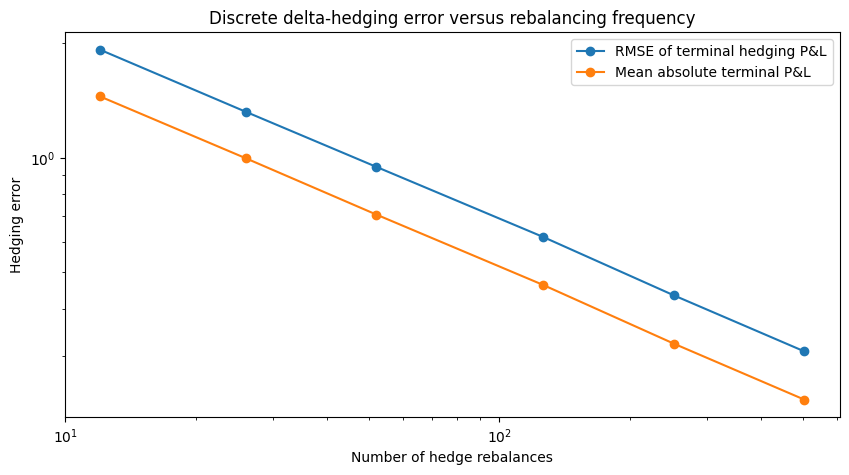

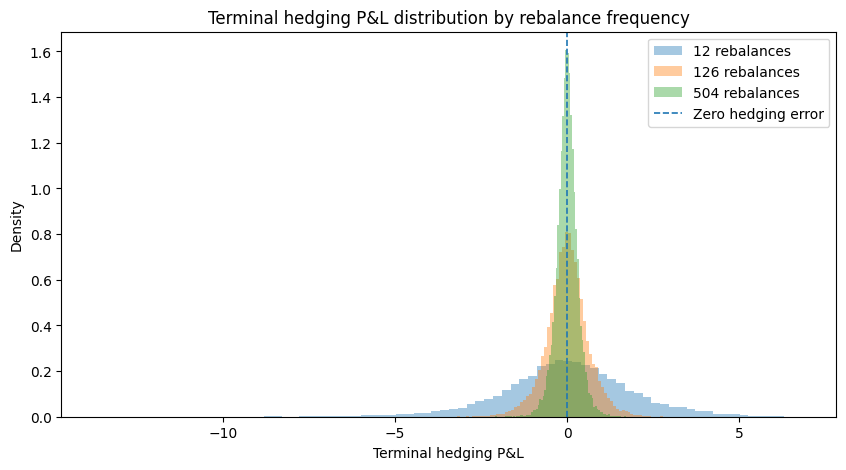

In [9]:
# ============================================================
# Cell 10 — Many-path discrete delta-hedging error
# ============================================================

def run_vectorized_delta_hedge_pnl(
    cfg: BSMModelConfig,
    n_paths: int,
    n_steps: int,
    option_type: OptionType = "call",
    measure: MeasureType = "Q",
    hedge_sigma: float | None = None,
    seed: int = 0,
) -> np.ndarray:
    """
    Run a vectorized discrete delta-hedging experiment across many paths.

    Sign convention
    ---------------
    The hedger sells one option at t = 0, receives the option premium, and
    hedges the short option by holding the Black-Scholes delta in shares.

    Initial cash account:

        cash_0 = option_premium - delta_0 * S_0

    At each hedge date before maturity:

        1. cash accrues at the risk-free rate
        2. stock position is rebalanced to the new delta
        3. the rebalance cost is paid from the cash account

    At maturity:

        terminal_pnl = delta_{T-} S_T + cash_T - payoff(S_T)

    Under exact Black-Scholes assumptions and continuous rebalancing, this
    terminal P&L would be zero. Under discrete rebalancing, it is a distribution.

    Notes
    -----
    This implementation assumes q = 0. With continuous dividends, the stock
    position receives dividend cash flows that must be explicitly credited to
    the cash account.
    """
    if option_type not in {"call", "put"}:
        raise ValueError("option_type must be either 'call' or 'put'.")

    if abs(cfg.q) > 1e-14:
        raise NotImplementedError(
            "This hedging experiment currently assumes q = 0. "
            "Nonzero dividend yield requires explicit dividend cash-flow bookkeeping."
        )

    if n_paths <= 0:
        raise ValueError("n_paths must be positive.")
    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")

    hedge_sigma = cfg.sigma if hedge_sigma is None else hedge_sigma

    if hedge_sigma <= 0:
        raise ValueError("hedge_sigma must be strictly positive.")

    time_grid, paths = simulate_gbm_paths(
        cfg=cfg,
        n_paths=n_paths,
        n_steps=n_steps,
        measure=measure,
        seed=seed,
    )

    dt = cfg.T / n_steps

    option_premium = float(
        bsm_price(
            S=cfg.S0,
            K=cfg.K,
            tau=cfg.T,
            r=cfg.r,
            q=cfg.q,
            sigma=hedge_sigma,
            option_type=option_type,
        )
    )

    delta = np.full(
        shape=n_paths,
        fill_value=float(
            bsm_delta(
                S=cfg.S0,
                K=cfg.K,
                tau=cfg.T,
                r=cfg.r,
                q=cfg.q,
                sigma=hedge_sigma,
                option_type=option_type,
            )
        ),
        dtype=float,
    )

    cash = option_premium - delta * cfg.S0

    # Rebalance at each intermediate hedge date, not at maturity.
    for i in range(1, n_steps):
        t_i = float(time_grid[i])
        tau_i = max(cfg.T - t_i, 0.0)
        S_i = paths[:, i]

        cash *= math.exp(cfg.r * dt)

        new_delta = bsm_delta(
            S=S_i,
            K=cfg.K,
            tau=tau_i,
            r=cfg.r,
            q=cfg.q,
            sigma=hedge_sigma,
            option_type=option_type,
        )

        cash -= (new_delta - delta) * S_i
        delta = new_delta

    # Accrue cash from last rebalance date to maturity.
    cash *= math.exp(cfg.r * dt)

    S_T = paths[:, -1]

    payoff_T = option_payoff(
        terminal_prices=S_T,
        K=cfg.K,
        option_type=option_type,
    )

    hedge_assets_T = delta * S_T + cash
    terminal_pnl = hedge_assets_T - payoff_T

    return terminal_pnl


def summarize_hedging_pnl(
    pnl: np.ndarray,
    n_steps: int,
    n_paths: int,
    option_type: OptionType,
    hedge_sigma: float,
    true_sigma: float,
) -> dict[str, float | int | str]:
    """
    Summarize a terminal hedging P&L distribution.
    """
    pnl = np.asarray(pnl, dtype=float)

    mean_pnl = float(np.mean(pnl))
    std_pnl = float(np.std(pnl, ddof=1))
    rmse_pnl = float(np.sqrt(np.mean(pnl**2)))
    mean_abs_pnl = float(np.mean(np.abs(pnl)))

    return {
        "option_type": option_type,
        "n_steps": int(n_steps),
        "n_paths": int(n_paths),
        "dt": float(model_cfg.T / n_steps),
        "hedge_sigma": float(hedge_sigma),
        "true_sigma": float(true_sigma),
        "mean_pnl": mean_pnl,
        "std_pnl": std_pnl,
        "rmse_pnl": rmse_pnl,
        "mean_abs_pnl": mean_abs_pnl,
        "median_pnl": float(np.median(pnl)),
        "p01_pnl": float(np.quantile(pnl, 0.01)),
        "p05_pnl": float(np.quantile(pnl, 0.05)),
        "p95_pnl": float(np.quantile(pnl, 0.95)),
        "p99_pnl": float(np.quantile(pnl, 0.99)),
    }


def run_hedging_frequency_experiment(
    cfg: BSMModelConfig,
    sim_cfg: SimulationConfig,
    option_type: OptionType = "call",
    hedge_sigma: float | None = None,
    n_hedge_paths: int | None = None,
) -> tuple[pd.DataFrame, dict[int, np.ndarray]]:
    """
    Run discrete hedging experiments across multiple rebalancing frequencies.

    The number of paths is capped by default because hedging simulations are
    path-dependent and heavier than terminal-only Monte Carlo pricing.
    """
    hedge_sigma = cfg.sigma if hedge_sigma is None else hedge_sigma
    n_hedge_paths = min(20_000, sim_cfg.n_paths) if n_hedge_paths is None else n_hedge_paths

    rows = []
    pnl_by_steps = {}

    for j, n_steps in enumerate(sim_cfg.hedge_step_grid):
        pnl = run_vectorized_delta_hedge_pnl(
            cfg=cfg,
            n_paths=n_hedge_paths,
            n_steps=n_steps,
            option_type=option_type,
            measure="Q",
            hedge_sigma=hedge_sigma,
            seed=sim_cfg.seed + 30_000 + j,
        )

        pnl_by_steps[int(n_steps)] = pnl

        rows.append(
            summarize_hedging_pnl(
                pnl=pnl,
                n_steps=n_steps,
                n_paths=n_hedge_paths,
                option_type=option_type,
                hedge_sigma=hedge_sigma,
                true_sigma=cfg.sigma,
            )
        )

    summary = pd.DataFrame(rows).sort_values("n_steps").reset_index(drop=True)

    return summary, pnl_by_steps


# ------------------------------------------------------------
# Run many-path hedge-frequency experiment
# ------------------------------------------------------------

hedging_frequency_summary, hedge_pnl_by_steps = run_hedging_frequency_experiment(
    cfg=model_cfg,
    sim_cfg=sim_cfg,
    option_type="call",
    hedge_sigma=model_cfg.sigma,
    n_hedge_paths=min(20_000, sim_cfg.n_paths),
)

print("Discrete delta-hedging error by rebalancing frequency")
display(hedging_frequency_summary)


# ------------------------------------------------------------
# Compact convergence interpretation
# ------------------------------------------------------------

first_row = hedging_frequency_summary.iloc[0]
last_row = hedging_frequency_summary.iloc[-1]

hedging_convergence_summary = pd.DataFrame(
    {
        "value": {
            "lowest_frequency_steps": int(first_row["n_steps"]),
            "highest_frequency_steps": int(last_row["n_steps"]),
            "lowest_frequency_rmse": float(first_row["rmse_pnl"]),
            "highest_frequency_rmse": float(last_row["rmse_pnl"]),
            "rmse_change": float(last_row["rmse_pnl"] - first_row["rmse_pnl"]),
            "rmse_reduction_pct": float(
                100.0 * (first_row["rmse_pnl"] - last_row["rmse_pnl"]) / first_row["rmse_pnl"]
            ),
            "lowest_frequency_std": float(first_row["std_pnl"]),
            "highest_frequency_std": float(last_row["std_pnl"]),
        },
        "interpretation": {
            "lowest_frequency_steps": "coarsest hedge grid",
            "highest_frequency_steps": "finest hedge grid",
            "lowest_frequency_rmse": "hedging-error RMSE at coarsest hedge grid",
            "highest_frequency_rmse": "hedging-error RMSE at finest hedge grid",
            "rmse_change": "negative means hedging RMSE declined",
            "rmse_reduction_pct": "percentage decline in hedging-error RMSE",
            "lowest_frequency_std": "P&L standard deviation at coarsest hedge grid",
            "highest_frequency_std": "P&L standard deviation at finest hedge grid",
        },
    }
)

print("Hedging-error convergence summary")
display(hedging_convergence_summary)

if float(last_row["rmse_pnl"]) < float(first_row["rmse_pnl"]):
    print("Discrete hedging convergence check: PASS")
else:
    print("Discrete hedging convergence check: REVIEW")

print(
    "Interpretation: under the correct BSM model, discrete hedging error should shrink "
    "as rebalancing becomes more frequent, but it does not vanish at finite frequency."
)


# ------------------------------------------------------------
# Visualization 1: hedging RMSE versus rebalance frequency
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    hedging_frequency_summary["n_steps"],
    hedging_frequency_summary["rmse_pnl"],
    marker="o",
    label="RMSE of terminal hedging P&L",
)

ax.plot(
    hedging_frequency_summary["n_steps"],
    hedging_frequency_summary["mean_abs_pnl"],
    marker="o",
    label="Mean absolute terminal P&L",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Discrete delta-hedging error versus rebalancing frequency")
ax.set_xlabel("Number of hedge rebalances")
ax.set_ylabel("Hedging error")
ax.legend()

plt.show()


# ------------------------------------------------------------
# Visualization 2: hedging P&L distributions for selected frequencies
# ------------------------------------------------------------

selected_steps = [
    int(hedging_frequency_summary["n_steps"].iloc[0]),
    int(hedging_frequency_summary["n_steps"].iloc[len(hedging_frequency_summary) // 2]),
    int(hedging_frequency_summary["n_steps"].iloc[-1]),
]

fig, ax = plt.subplots(figsize=(10, 5))

for n_steps in selected_steps:
    pnl = hedge_pnl_by_steps[n_steps]

    ax.hist(
        pnl,
        bins=80,
        alpha=0.40,
        density=True,
        label=f"{n_steps} rebalances",
    )

ax.axvline(0.0, linestyle="--", linewidth=1.2, label="Zero hedging error")

ax.set_title("Terminal hedging P&L distribution by rebalance frequency")
ax.set_xlabel("Terminal hedging P&L")
ax.set_ylabel("Density")
ax.legend()

plt.show()

Wrong-volatility hedge stress: pricing error versus hedging error


,scenario,option_type,n_steps,n_paths,true_sigma,premium_sigma,hedge_sigma,true_bsm_premium,charged_premium,initial_pricing_gap,pricing_gap_grown_to_T,mean_pnl,std_pnl,rmse_pnl,mean_abs_pnl,median_pnl,p01_pnl,p05_pnl,p95_pnl,p99_pnl
0,"correct premium, correct hedge",call,252,20000,0.200000,0.200000,0.200000,10.450584,10.450584,0.000000,0.000000,-0.000029,0.439628,0.439617,0.327394,0.000986,-1.203160,-0.706937,0.714668,1.128336
1,"correct premium, low-vol hedge",call,252,20000,0.200000,0.200000,0.150000,10.450584,10.450584,0.000000,0.000000,-0.003193,0.978193,0.978174,0.793518,0.106279,-2.620054,-1.754489,1.364420,1.603514
2,"correct premium, high-vol hedge",call,252,20000,0.200000,0.200000,0.250000,10.450584,10.450584,0.000000,0.000000,0.002413,0.797862,0.797846,0.649806,-0.056743,-1.486475,-1.197507,1.400459,1.978570
3,"low-vol premium, low-vol hedge",call,252,20000,0.200000,0.150000,0.150000,10.450584,8.591658,-1.858925,-1.954234,-1.957428,0.978193,2.188227,1.957453,-1.847955,-4.574289,-3.708723,-0.589815,-0.350720
4,"high-vol premium, high-vol hedge",call,252,20000,0.200000,0.250000,0.250000,10.450584,12.335999,1.885415,1.982083,1.984496,0.797862,2.138873,1.984496,1.925340,0.495608,0.784576,3.382541,3.960652


Volatility-stress interpretation


,scenario,initial_pricing_gap,pricing_gap_grown_to_T,mean_pnl,std_pnl,rmse_pnl,interpretation
0,"correct premium, correct hedge",0.000000,0.000000,-0.000029,0.439628,0.439617,Baseline: correct premium and correct hedge vo...
1,"correct premium, low-vol hedge",0.000000,0.000000,-0.003193,0.978193,0.978174,Isolated hedge-model error: initial premium is...
2,"correct premium, high-vol hedge",0.000000,0.000000,0.002413,0.797862,0.797846,Isolated hedge-model error: initial premium is...
3,"low-vol premium, low-vol hedge",-1.858925,-1.954234,-1.957428,0.978193,2.188227,Pricing plus hedge-model error: the option is ...
4,"high-vol premium, high-vol hedge",1.885415,1.982083,1.984496,0.797862,2.138873,Pricing plus hedge-model error: the option is ...


Volatility-stress validation


,value,interpretation
baseline_rmse,0.439617,RMSE using correct premium and correct hedge s...
low_vol_hedge_only_rmse,0.978174,RMSE using fair premium but wrong low-vol hedg...
low_vol_full_mean_pnl,-1.957428,mean P&L when low volatility is used for both ...
low_vol_pricing_gap_grown_to_T,-1.954234,initial low-vol mispricing carried to maturity
mean_minus_pricing_gap_T,-0.003193,residual difference after accounting for prici...


Wrong-volatility hedge-only stress increases hedging RMSE: PASS
Interpretation: wrong volatility has two separate effects. It can produce a wrong initial price, and it can produce a wrong hedge ratio. The table separates those effects instead of mixing them together.


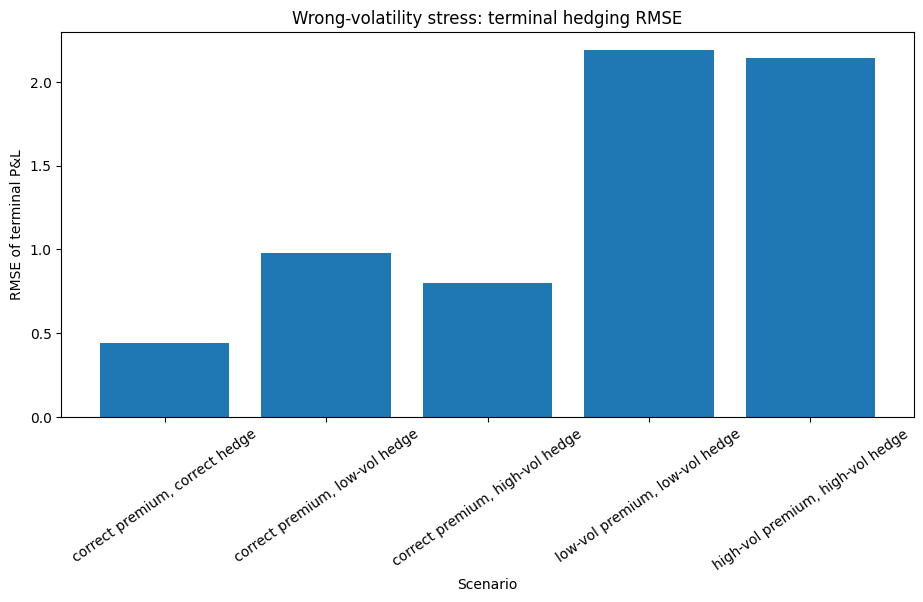

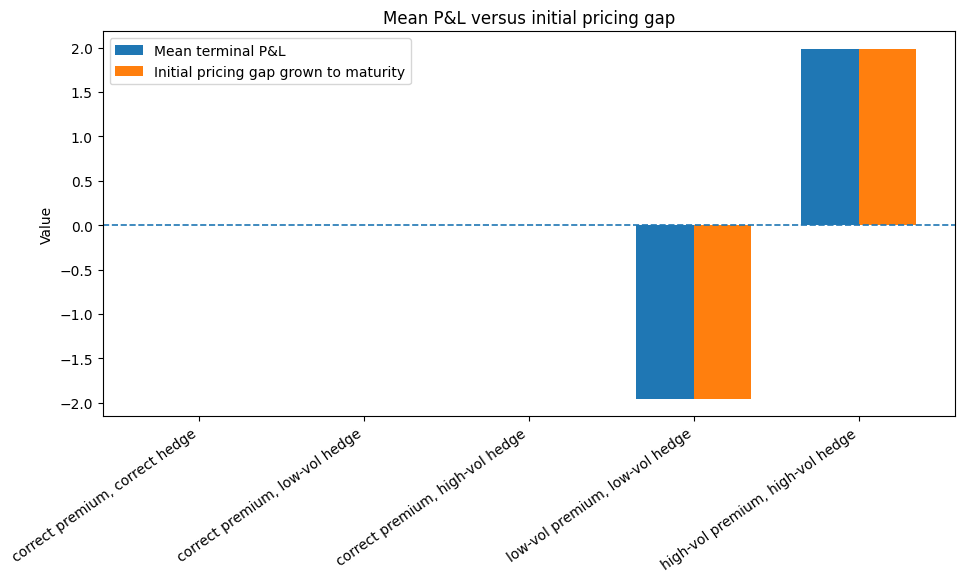

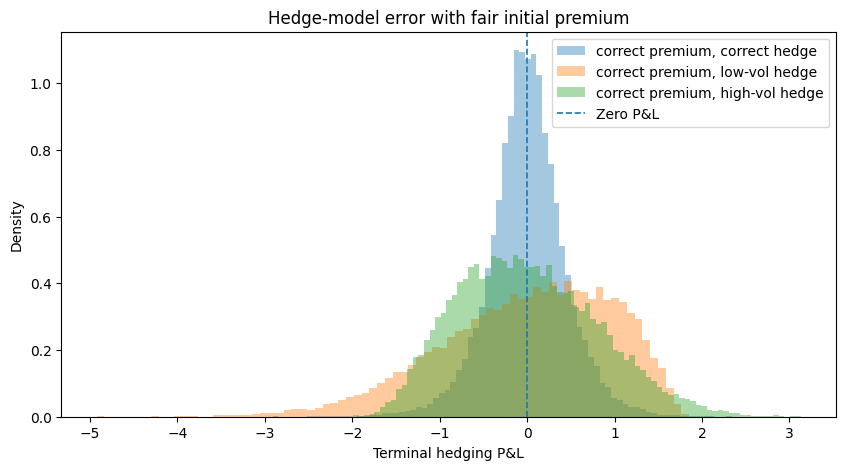

In [10]:
# ============================================================
# Cell 11 — Wrong-volatility hedge stress: pricing error vs hedging error
# ============================================================

def run_delta_hedge_pnl_on_existing_paths(
    time_grid: np.ndarray,
    paths: np.ndarray,
    cfg: BSMModelConfig,
    option_type: OptionType = "call",
    premium_sigma: float | None = None,
    hedge_sigma: float | None = None,
) -> np.ndarray:
    """
    Run a discrete delta hedge on pre-simulated stock paths.

    This function separates two different modeling choices:

    1. premium_sigma
        The volatility used to set the initial option premium received.

    2. hedge_sigma
        The volatility used to compute the hedge delta through time.

    This distinction matters.

    If premium_sigma is the true model volatility but hedge_sigma is wrong,
    the experiment isolates dynamic hedging error from using the wrong delta.

    If both premium_sigma and hedge_sigma are wrong, the experiment combines
    initial mispricing with dynamic hedging error.
    """
    if option_type not in {"call", "put"}:
        raise ValueError("option_type must be either 'call' or 'put'.")

    if abs(cfg.q) > 1e-14:
        raise NotImplementedError(
            "This hedge stress assumes q = 0. "
            "Nonzero dividend yield requires dividend cash-flow bookkeeping."
        )

    if paths.ndim != 2:
        raise ValueError("paths must be a two-dimensional array.")

    n_paths, n_time_points = paths.shape

    if len(time_grid) != n_time_points:
        raise ValueError("time_grid length must match paths.shape[1].")

    if n_time_points < 2:
        raise ValueError("paths must contain at least two time points.")

    if not np.all(np.diff(time_grid) > 0):
        raise ValueError("time_grid must be strictly increasing.")

    premium_sigma = cfg.sigma if premium_sigma is None else premium_sigma
    hedge_sigma = cfg.sigma if hedge_sigma is None else hedge_sigma

    if premium_sigma <= 0:
        raise ValueError("premium_sigma must be strictly positive.")
    if hedge_sigma <= 0:
        raise ValueError("hedge_sigma must be strictly positive.")

    n_steps = n_time_points - 1

    option_premium = float(
        bsm_price(
            S=cfg.S0,
            K=cfg.K,
            tau=cfg.T,
            r=cfg.r,
            q=cfg.q,
            sigma=premium_sigma,
            option_type=option_type,
        )
    )

    delta = np.full(
        shape=n_paths,
        fill_value=float(
            bsm_delta(
                S=cfg.S0,
                K=cfg.K,
                tau=cfg.T,
                r=cfg.r,
                q=cfg.q,
                sigma=hedge_sigma,
                option_type=option_type,
            )
        ),
        dtype=float,
    )

    cash = option_premium - delta * cfg.S0

    for i in range(1, n_steps):
        dt = float(time_grid[i] - time_grid[i - 1])
        tau_i = max(cfg.T - float(time_grid[i]), 0.0)
        S_i = paths[:, i]

        cash *= math.exp(cfg.r * dt)

        new_delta = bsm_delta(
            S=S_i,
            K=cfg.K,
            tau=tau_i,
            r=cfg.r,
            q=cfg.q,
            sigma=hedge_sigma,
            option_type=option_type,
        )

        cash -= (new_delta - delta) * S_i
        delta = new_delta

    final_dt = float(time_grid[-1] - time_grid[-2])
    cash *= math.exp(cfg.r * final_dt)

    S_T = paths[:, -1]

    payoff_T = option_payoff(
        terminal_prices=S_T,
        K=cfg.K,
        option_type=option_type,
    )

    hedge_assets_T = delta * S_T + cash
    terminal_pnl = hedge_assets_T - payoff_T

    return terminal_pnl


def summarize_vol_stress_pnl(
    pnl: np.ndarray,
    cfg: BSMModelConfig,
    scenario: str,
    option_type: OptionType,
    n_steps: int,
    n_paths: int,
    premium_sigma: float,
    hedge_sigma: float,
) -> dict[str, float | int | str]:
    """
    Summarize a wrong-volatility hedge stress scenario.
    """
    pnl = np.asarray(pnl, dtype=float)

    true_premium = float(
        bsm_price(
            S=cfg.S0,
            K=cfg.K,
            tau=cfg.T,
            r=cfg.r,
            q=cfg.q,
            sigma=cfg.sigma,
            option_type=option_type,
        )
    )

    charged_premium = float(
        bsm_price(
            S=cfg.S0,
            K=cfg.K,
            tau=cfg.T,
            r=cfg.r,
            q=cfg.q,
            sigma=premium_sigma,
            option_type=option_type,
        )
    )

    initial_pricing_gap = charged_premium - true_premium
    pricing_gap_grown_to_T = initial_pricing_gap * math.exp(cfg.r * cfg.T)

    mean_pnl = float(np.mean(pnl))
    std_pnl = float(np.std(pnl, ddof=1))
    rmse_pnl = float(np.sqrt(np.mean(pnl**2)))

    return {
        "scenario": scenario,
        "option_type": option_type,
        "n_steps": int(n_steps),
        "n_paths": int(n_paths),
        "true_sigma": float(cfg.sigma),
        "premium_sigma": float(premium_sigma),
        "hedge_sigma": float(hedge_sigma),
        "true_bsm_premium": true_premium,
        "charged_premium": charged_premium,
        "initial_pricing_gap": initial_pricing_gap,
        "pricing_gap_grown_to_T": pricing_gap_grown_to_T,
        "mean_pnl": mean_pnl,
        "std_pnl": std_pnl,
        "rmse_pnl": rmse_pnl,
        "mean_abs_pnl": float(np.mean(np.abs(pnl))),
        "median_pnl": float(np.median(pnl)),
        "p01_pnl": float(np.quantile(pnl, 0.01)),
        "p05_pnl": float(np.quantile(pnl, 0.05)),
        "p95_pnl": float(np.quantile(pnl, 0.95)),
        "p99_pnl": float(np.quantile(pnl, 0.99)),
    }


# ------------------------------------------------------------
# Use common stock paths for all volatility-stress scenarios
# ------------------------------------------------------------

stress_n_paths = min(20_000, sim_cfg.n_paths)
stress_n_steps = 252

stress_time_grid, stress_paths_Q = simulate_gbm_paths(
    cfg=model_cfg,
    n_paths=stress_n_paths,
    n_steps=stress_n_steps,
    measure="Q",
    seed=sim_cfg.seed + 40_000,
)

low_sigma = 0.15
true_sigma = model_cfg.sigma
high_sigma = 0.25

stress_scenarios = [
    {
        "scenario": "correct premium, correct hedge",
        "premium_sigma": true_sigma,
        "hedge_sigma": true_sigma,
    },
    {
        "scenario": "correct premium, low-vol hedge",
        "premium_sigma": true_sigma,
        "hedge_sigma": low_sigma,
    },
    {
        "scenario": "correct premium, high-vol hedge",
        "premium_sigma": true_sigma,
        "hedge_sigma": high_sigma,
    },
    {
        "scenario": "low-vol premium, low-vol hedge",
        "premium_sigma": low_sigma,
        "hedge_sigma": low_sigma,
    },
    {
        "scenario": "high-vol premium, high-vol hedge",
        "premium_sigma": high_sigma,
        "hedge_sigma": high_sigma,
    },
]

stress_rows = []
stress_pnl_by_scenario = {}

for spec in stress_scenarios:
    pnl = run_delta_hedge_pnl_on_existing_paths(
        time_grid=stress_time_grid,
        paths=stress_paths_Q,
        cfg=model_cfg,
        option_type="call",
        premium_sigma=spec["premium_sigma"],
        hedge_sigma=spec["hedge_sigma"],
    )

    stress_pnl_by_scenario[spec["scenario"]] = pnl

    stress_rows.append(
        summarize_vol_stress_pnl(
            pnl=pnl,
            cfg=model_cfg,
            scenario=spec["scenario"],
            option_type="call",
            n_steps=stress_n_steps,
            n_paths=stress_n_paths,
            premium_sigma=spec["premium_sigma"],
            hedge_sigma=spec["hedge_sigma"],
        )
    )

vol_stress_summary = pd.DataFrame(stress_rows)

print("Wrong-volatility hedge stress: pricing error versus hedging error")
display(vol_stress_summary)


# ------------------------------------------------------------
# Interpretation table
# ------------------------------------------------------------

interpretation_rows = []

for _, row in vol_stress_summary.iterrows():
    scenario = row["scenario"]

    if math.isclose(row["premium_sigma"], true_sigma) and math.isclose(row["hedge_sigma"], true_sigma):
        interpretation = (
            "Baseline: correct premium and correct hedge volatility. "
            "Mean P&L should be near zero and dispersion is mostly discrete hedging error."
        )
    elif math.isclose(row["premium_sigma"], true_sigma):
        interpretation = (
            "Isolated hedge-model error: initial premium is fair, but delta is computed "
            "with the wrong volatility. Mean P&L should remain near zero, but dispersion can worsen."
        )
    else:
        interpretation = (
            "Pricing plus hedge-model error: the option is initially charged using the wrong "
            "volatility and hedged with that same wrong volatility. Mean P&L should reflect "
            "the initial pricing gap grown through time."
        )

    interpretation_rows.append(
        {
            "scenario": scenario,
            "initial_pricing_gap": float(row["initial_pricing_gap"]),
            "pricing_gap_grown_to_T": float(row["pricing_gap_grown_to_T"]),
            "mean_pnl": float(row["mean_pnl"]),
            "std_pnl": float(row["std_pnl"]),
            "rmse_pnl": float(row["rmse_pnl"]),
            "interpretation": interpretation,
        }
    )

vol_stress_interpretation = pd.DataFrame(interpretation_rows)

print("Volatility-stress interpretation")
display(vol_stress_interpretation)


# ------------------------------------------------------------
# Validation checks
# ------------------------------------------------------------

baseline_rmse = float(
    vol_stress_summary.loc[
        vol_stress_summary["scenario"] == "correct premium, correct hedge",
        "rmse_pnl",
    ].iloc[0]
)

isolated_wrong_hedge_rmse = float(
    vol_stress_summary.loc[
        vol_stress_summary["scenario"] == "correct premium, low-vol hedge",
        "rmse_pnl",
    ].iloc[0]
)

low_vol_full_mean = float(
    vol_stress_summary.loc[
        vol_stress_summary["scenario"] == "low-vol premium, low-vol hedge",
        "mean_pnl",
    ].iloc[0]
)

low_vol_full_pricing_gap_T = float(
    vol_stress_summary.loc[
        vol_stress_summary["scenario"] == "low-vol premium, low-vol hedge",
        "pricing_gap_grown_to_T",
    ].iloc[0]
)

stress_validation = pd.DataFrame(
    {
        "value": {
            "baseline_rmse": baseline_rmse,
            "low_vol_hedge_only_rmse": isolated_wrong_hedge_rmse,
            "low_vol_full_mean_pnl": low_vol_full_mean,
            "low_vol_pricing_gap_grown_to_T": low_vol_full_pricing_gap_T,
            "mean_minus_pricing_gap_T": low_vol_full_mean - low_vol_full_pricing_gap_T,
        },
        "interpretation": {
            "baseline_rmse": "RMSE using correct premium and correct hedge sigma",
            "low_vol_hedge_only_rmse": "RMSE using fair premium but wrong low-vol hedge delta",
            "low_vol_full_mean_pnl": "mean P&L when low volatility is used for both premium and hedge",
            "low_vol_pricing_gap_grown_to_T": "initial low-vol mispricing carried to maturity",
            "mean_minus_pricing_gap_T": "residual difference after accounting for pricing gap",
        },
    }
)

print("Volatility-stress validation")
display(stress_validation)

if isolated_wrong_hedge_rmse > baseline_rmse:
    print("Wrong-volatility hedge-only stress increases hedging RMSE: PASS")
else:
    print("Wrong-volatility hedge-only stress increases hedging RMSE: REVIEW")

print(
    "Interpretation: wrong volatility has two separate effects. "
    "It can produce a wrong initial price, and it can produce a wrong hedge ratio. "
    "The table separates those effects instead of mixing them together."
)


# ------------------------------------------------------------
# Visualization 1: RMSE by scenario
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    vol_stress_summary["scenario"],
    vol_stress_summary["rmse_pnl"],
)

ax.set_title("Wrong-volatility stress: terminal hedging RMSE")
ax.set_xlabel("Scenario")
ax.set_ylabel("RMSE of terminal P&L")
ax.tick_params(axis="x", rotation=35)

plt.show()


# ------------------------------------------------------------
# Visualization 2: mean P&L versus pricing gap grown to maturity
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(vol_stress_summary))
bar_width = 0.35

ax.bar(
    x - bar_width / 2,
    vol_stress_summary["mean_pnl"],
    width=bar_width,
    label="Mean terminal P&L",
)

ax.bar(
    x + bar_width / 2,
    vol_stress_summary["pricing_gap_grown_to_T"],
    width=bar_width,
    label="Initial pricing gap grown to maturity",
)

ax.axhline(0.0, linestyle="--", linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(vol_stress_summary["scenario"], rotation=35, ha="right")
ax.set_title("Mean P&L versus initial pricing gap")
ax.set_ylabel("Value")
ax.legend()

plt.show()


# ------------------------------------------------------------
# Visualization 3: P&L distributions for selected scenarios
# ------------------------------------------------------------

selected_stress_scenarios = [
    "correct premium, correct hedge",
    "correct premium, low-vol hedge",
    "correct premium, high-vol hedge",
]

fig, ax = plt.subplots(figsize=(10, 5))

for scenario in selected_stress_scenarios:
    ax.hist(
        stress_pnl_by_scenario[scenario],
        bins=80,
        alpha=0.40,
        density=True,
        label=scenario,
    )

ax.axvline(0.0, linestyle="--", linewidth=1.2, label="Zero P&L")

ax.set_title("Hedge-model error with fair initial premium")
ax.set_xlabel("Terminal hedging P&L")
ax.set_ylabel("Density")
ax.legend()

plt.show()

Physical-drift stress for realized discrete hedging P&L


,scenario,path_measure,path_drift,pricing_drift_r_minus_q,drift_gap_vs_pricing,n_steps,n_paths,mean_pnl,std_pnl,rmse_pnl,mean_abs_pnl,median_pnl,p01_pnl,p05_pnl,p95_pnl,p99_pnl
0,Q paths: pricing drift,Q,0.050000,0.050000,0.000000,252,20000,0.001765,0.434609,0.434602,0.323293,0.000506,-1.165851,-0.698206,0.710514,1.102885
1,P paths: mu = 0.00%,P,0.000000,0.050000,-0.050000,252,20000,0.001795,0.438824,0.438817,0.326688,0.001237,-1.160846,-0.716623,0.713236,1.125994
2,P paths: mu = 5.00%,P,0.050000,0.050000,0.000000,252,20000,0.001765,0.434609,0.434602,0.323293,0.000506,-1.165851,-0.698206,0.710514,1.102885
3,P paths: mu = 10.00%,P,0.100000,0.050000,0.050000,252,20000,0.000600,0.425898,0.425887,0.316128,0.002944,-1.147533,-0.705986,0.692604,1.114280
4,P paths: mu = 15.00%,P,0.150000,0.050000,0.100000,252,20000,-0.004429,0.408950,0.408964,0.301557,-0.003106,-1.108803,-0.674713,0.650449,1.054293


Drift-stress interpretation


,scenario,path_drift,drift_gap_vs_pricing,mean_pnl,std_pnl,rmse_pnl,interpretation
0,Q paths: pricing drift,0.050000,0.000000,0.001765,0.434609,0.434602,Risk-neutral benchmark. The simulated path dri...
1,P paths: mu = 0.00%,0.000000,-0.050000,0.001795,0.438824,0.438817,Realized stock paths are generated with a phys...
2,P paths: mu = 5.00%,0.050000,0.000000,0.001765,0.434609,0.434602,"Physical-path label, but the physical drift eq..."
3,P paths: mu = 10.00%,0.100000,0.050000,0.000600,0.425898,0.425887,Realized stock paths are generated with a phys...
4,P paths: mu = 15.00%,0.150000,0.100000,-0.004429,0.408950,0.408964,Realized stock paths are generated with a phys...


Drift-stress validation


,value,interpretation
q_mean_pnl,0.001765,mean terminal P&L under Q benchmark
q_standard_error_of_mean,0.003073,standard error of the Q benchmark mean P&L
q_mean_pnl_in_standard_errors,0.574220,Q mean P&L scaled by its standard error
same_drift_P_minus_Q_mean_pnl,0.000000,P with mu=r-q should closely match Q mean P&L
same_drift_P_minus_Q_rmse_pnl,0.000000,P with mu=r-q should closely match Q RMSE
largest_abs_mean_pnl,0.004429,largest absolute mean P&L across drift scenarios
largest_rmse_pnl,0.438817,largest hedging-error RMSE across drift scenarios


Q benchmark mean hedging P&L near zero: PASS
P with mu = r - q matches Q paths under common shocks: PASS
Interpretation: mu is not an input to the BSM no-arbitrage price or delta. However, after the price and hedge rule are fixed, changing the realized path drift can change the empirical distribution of discrete hedging P&L.


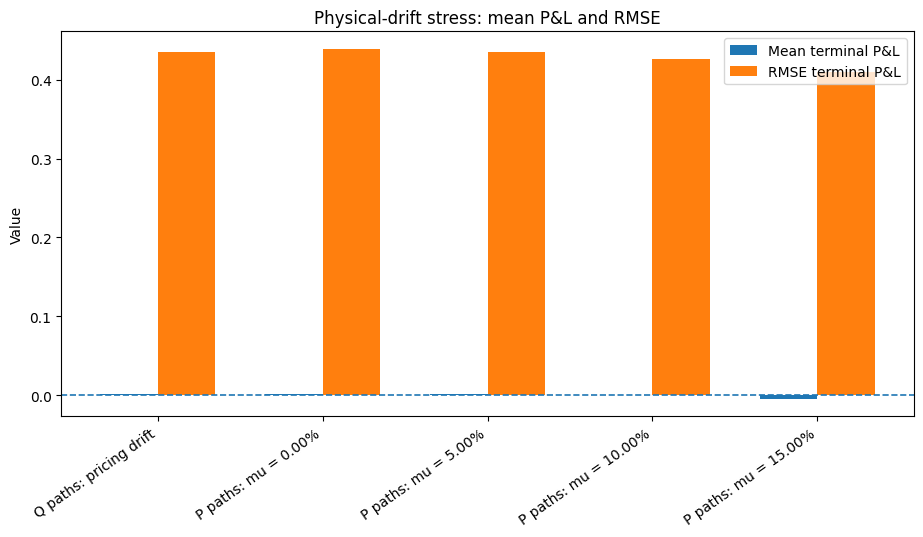

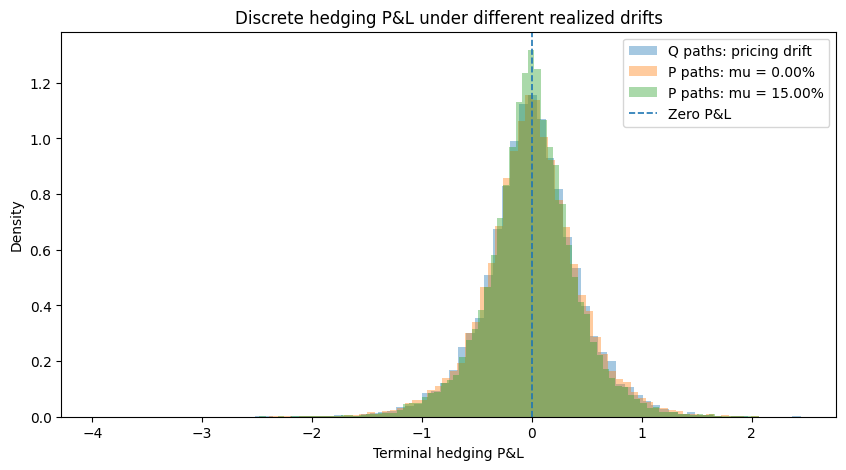

In [11]:
# ============================================================
# Cell 12 — Physical-drift stress for realized discrete hedging P&L
# ============================================================

def make_config_with_mu(
    cfg: BSMModelConfig,
    mu_value: float,
) -> BSMModelConfig:
    """
    Create a copy of the baseline configuration with a different physical drift.

    The pricing and hedge model will still use r, q, and sigma from the original
    baseline configuration. This modified config is only used to generate P-paths.
    """
    new_cfg = BSMModelConfig(
        S0=cfg.S0,
        K=cfg.K,
        T=cfg.T,
        r=cfg.r,
        q=cfg.q,
        mu=mu_value,
        sigma=cfg.sigma,
    )

    new_cfg.validate()

    return new_cfg


def summarize_drift_stress_pnl(
    pnl: np.ndarray,
    scenario: str,
    path_measure: str,
    path_drift: float,
    pricing_drift: float,
    n_steps: int,
    n_paths: int,
) -> dict[str, float | int | str]:
    """
    Summarize terminal hedging P&L when the realized path drift changes.

    The option premium and hedge delta still come from the same BSM pricing model.
    Only the simulated realized stock-path distribution changes.
    """
    pnl = np.asarray(pnl, dtype=float)

    return {
        "scenario": scenario,
        "path_measure": path_measure,
        "path_drift": float(path_drift),
        "pricing_drift_r_minus_q": float(pricing_drift),
        "drift_gap_vs_pricing": float(path_drift - pricing_drift),
        "n_steps": int(n_steps),
        "n_paths": int(n_paths),
        "mean_pnl": float(np.mean(pnl)),
        "std_pnl": float(np.std(pnl, ddof=1)),
        "rmse_pnl": float(np.sqrt(np.mean(pnl**2))),
        "mean_abs_pnl": float(np.mean(np.abs(pnl))),
        "median_pnl": float(np.median(pnl)),
        "p01_pnl": float(np.quantile(pnl, 0.01)),
        "p05_pnl": float(np.quantile(pnl, 0.05)),
        "p95_pnl": float(np.quantile(pnl, 0.95)),
        "p99_pnl": float(np.quantile(pnl, 0.99)),
    }


# ------------------------------------------------------------
# Drift-stress setup
# ------------------------------------------------------------

drift_stress_n_paths = min(20_000, sim_cfg.n_paths)
drift_stress_n_steps = 252
pricing_drift = model_cfg.r - model_cfg.q

physical_drift_grid = (
    0.00,
    pricing_drift,
    model_cfg.mu,
    0.15,
)

drift_stress_rows = []
drift_pnl_by_scenario = {}

# ------------------------------------------------------------
# Benchmark: Q paths with correct premium and correct hedge
# ------------------------------------------------------------

q_time_grid, q_paths = simulate_gbm_paths(
    cfg=model_cfg,
    n_paths=drift_stress_n_paths,
    n_steps=drift_stress_n_steps,
    measure="Q",
    seed=sim_cfg.seed + 50_000,
)

q_pnl = run_delta_hedge_pnl_on_existing_paths(
    time_grid=q_time_grid,
    paths=q_paths,
    cfg=model_cfg,
    option_type="call",
    premium_sigma=model_cfg.sigma,
    hedge_sigma=model_cfg.sigma,
)

q_scenario = "Q paths: pricing drift"
drift_pnl_by_scenario[q_scenario] = q_pnl

drift_stress_rows.append(
    summarize_drift_stress_pnl(
        pnl=q_pnl,
        scenario=q_scenario,
        path_measure="Q",
        path_drift=pricing_drift,
        pricing_drift=pricing_drift,
        n_steps=drift_stress_n_steps,
        n_paths=drift_stress_n_paths,
    )
)


# ------------------------------------------------------------
# P paths with alternative physical drifts
# ------------------------------------------------------------

for j, mu_value in enumerate(physical_drift_grid):
    path_cfg = make_config_with_mu(model_cfg, mu_value)

    p_time_grid, p_paths = simulate_gbm_paths(
        cfg=path_cfg,
        n_paths=drift_stress_n_paths,
        n_steps=drift_stress_n_steps,
        measure="P",
        seed=sim_cfg.seed + 50_000,
    )

    p_pnl = run_delta_hedge_pnl_on_existing_paths(
        time_grid=p_time_grid,
        paths=p_paths,
        cfg=model_cfg,
        option_type="call",
        premium_sigma=model_cfg.sigma,
        hedge_sigma=model_cfg.sigma,
    )

    scenario = f"P paths: mu = {mu_value:.2%}"
    drift_pnl_by_scenario[scenario] = p_pnl

    drift_stress_rows.append(
        summarize_drift_stress_pnl(
            pnl=p_pnl,
            scenario=scenario,
            path_measure="P",
            path_drift=mu_value,
            pricing_drift=pricing_drift,
            n_steps=drift_stress_n_steps,
            n_paths=drift_stress_n_paths,
        )
    )


drift_stress_summary = pd.DataFrame(drift_stress_rows)

print("Physical-drift stress for realized discrete hedging P&L")
display(drift_stress_summary)


# ------------------------------------------------------------
# Interpretation table
# ------------------------------------------------------------

drift_interpretation_rows = []

for _, row in drift_stress_summary.iterrows():
    if row["path_measure"] == "Q":
        interpretation = (
            "Risk-neutral benchmark. The simulated path drift matches the pricing drift, "
            "so the mean terminal P&L should be near zero up to Monte Carlo noise and "
            "discrete hedging error."
        )
    elif abs(row["drift_gap_vs_pricing"]) < 1e-12:
        interpretation = (
            "Physical-path label, but the physical drift equals the pricing drift. "
            "This should behave like the Q benchmark when the same shocks are used."
        )
    else:
        interpretation = (
            "Realized stock paths are generated with a physical drift different from the "
            "pricing drift. The BSM price and delta still do not use mu, but the realized "
            "discrete hedging P&L distribution can change because different paths are realized."
        )

    drift_interpretation_rows.append(
        {
            "scenario": row["scenario"],
            "path_drift": float(row["path_drift"]),
            "drift_gap_vs_pricing": float(row["drift_gap_vs_pricing"]),
            "mean_pnl": float(row["mean_pnl"]),
            "std_pnl": float(row["std_pnl"]),
            "rmse_pnl": float(row["rmse_pnl"]),
            "interpretation": interpretation,
        }
    )

drift_stress_interpretation = pd.DataFrame(drift_interpretation_rows)

print("Drift-stress interpretation")
display(drift_stress_interpretation)


# ------------------------------------------------------------
# Validation checks
# ------------------------------------------------------------

q_mean_pnl = float(
    drift_stress_summary.loc[
        drift_stress_summary["scenario"] == q_scenario,
        "mean_pnl",
    ].iloc[0]
)

q_std_pnl = float(
    drift_stress_summary.loc[
        drift_stress_summary["scenario"] == q_scenario,
        "std_pnl",
    ].iloc[0]
)

q_standard_error_mean = q_std_pnl / math.sqrt(drift_stress_n_paths)

same_drift_row = drift_stress_summary[
    (drift_stress_summary["path_measure"] == "P")
    & (np.isclose(drift_stress_summary["path_drift"], pricing_drift))
].iloc[0]

same_drift_mean_gap = float(same_drift_row["mean_pnl"] - q_mean_pnl)
same_drift_rmse_gap = float(same_drift_row["rmse_pnl"] - drift_stress_summary.loc[
    drift_stress_summary["scenario"] == q_scenario,
    "rmse_pnl",
].iloc[0])

drift_validation = pd.DataFrame(
    {
        "value": {
            "q_mean_pnl": q_mean_pnl,
            "q_standard_error_of_mean": q_standard_error_mean,
            "q_mean_pnl_in_standard_errors": q_mean_pnl / q_standard_error_mean,
            "same_drift_P_minus_Q_mean_pnl": same_drift_mean_gap,
            "same_drift_P_minus_Q_rmse_pnl": same_drift_rmse_gap,
            "largest_abs_mean_pnl": float(np.max(np.abs(drift_stress_summary["mean_pnl"]))),
            "largest_rmse_pnl": float(np.max(drift_stress_summary["rmse_pnl"])),
        },
        "interpretation": {
            "q_mean_pnl": "mean terminal P&L under Q benchmark",
            "q_standard_error_of_mean": "standard error of the Q benchmark mean P&L",
            "q_mean_pnl_in_standard_errors": "Q mean P&L scaled by its standard error",
            "same_drift_P_minus_Q_mean_pnl": "P with mu=r-q should closely match Q mean P&L",
            "same_drift_P_minus_Q_rmse_pnl": "P with mu=r-q should closely match Q RMSE",
            "largest_abs_mean_pnl": "largest absolute mean P&L across drift scenarios",
            "largest_rmse_pnl": "largest hedging-error RMSE across drift scenarios",
        },
    }
)

print("Drift-stress validation")
display(drift_validation)

if abs(q_mean_pnl) < 3.0 * q_standard_error_mean:
    print("Q benchmark mean hedging P&L near zero: PASS")
else:
    print("Q benchmark mean hedging P&L near zero: REVIEW")

if abs(same_drift_mean_gap) < 1e-10 and abs(same_drift_rmse_gap) < 1e-10:
    print("P with mu = r - q matches Q paths under common shocks: PASS")
else:
    print("P with mu = r - q matches Q paths under common shocks: REVIEW")

print(
    "Interpretation: mu is not an input to the BSM no-arbitrage price or delta. "
    "However, after the price and hedge rule are fixed, changing the realized path drift "
    "can change the empirical distribution of discrete hedging P&L."
)


# ------------------------------------------------------------
# Visualization 1: mean P&L and RMSE by path drift
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

plot_rows = drift_stress_summary.copy()
x = np.arange(len(plot_rows))
bar_width = 0.35

ax.bar(
    x - bar_width / 2,
    plot_rows["mean_pnl"],
    width=bar_width,
    label="Mean terminal P&L",
)

ax.bar(
    x + bar_width / 2,
    plot_rows["rmse_pnl"],
    width=bar_width,
    label="RMSE terminal P&L",
)

ax.axhline(0.0, linestyle="--", linewidth=1.2)

ax.set_xticks(x)
ax.set_xticklabels(plot_rows["scenario"], rotation=35, ha="right")
ax.set_title("Physical-drift stress: mean P&L and RMSE")
ax.set_ylabel("Value")
ax.legend()

plt.show()


# ------------------------------------------------------------
# Visualization 2: selected drift-stress P&L distributions
# ------------------------------------------------------------

selected_drift_scenarios = [
    q_scenario,
    f"P paths: mu = {physical_drift_grid[0]:.2%}",
    f"P paths: mu = {physical_drift_grid[-1]:.2%}",
]

fig, ax = plt.subplots(figsize=(10, 5))

for scenario in selected_drift_scenarios:
    ax.hist(
        drift_pnl_by_scenario[scenario],
        bins=80,
        alpha=0.40,
        density=True,
        label=scenario,
    )

ax.axvline(0.0, linestyle="--", linewidth=1.2, label="Zero P&L")

ax.set_title("Discrete hedging P&L under different realized drifts")
ax.set_xlabel("Terminal hedging P&L")
ax.set_ylabel("Density")
ax.legend()

plt.show()

In [12]:
# ============================================================
# Cell 13 — Final validation ledger and handoff
# ============================================================

def make_audit_row(
    section: str,
    check: str,
    value: float | int | str | bool,
    threshold_or_expected: str,
    passed: bool,
    interpretation: str,
) -> dict[str, float | int | str | bool]:
    """
    Standard row format for the notebook validation ledger.
    """
    return {
        "section": section,
        "check": check,
        "value": value,
        "threshold_or_expected": threshold_or_expected,
        "status": "PASS" if passed else "REVIEW",
        "interpretation": interpretation,
    }


audit_rows = []


# ------------------------------------------------------------
# 1. Closed-form BSM benchmark checks
# ------------------------------------------------------------

audit_rows.append(
    make_audit_row(
        section="BSM benchmark",
        check="put-call parity error",
        value=float(parity_error),
        threshold_or_expected="absolute error < 1e-10",
        passed=abs(float(parity_error)) < 1e-10,
        interpretation=(
            "The call and put prices satisfy continuous-dividend put-call parity. "
            "This validates the closed-form benchmark used throughout the notebook."
        ),
    )
)

audit_rows.append(
    make_audit_row(
        section="BSM benchmark",
        check="finite baseline call and put prices",
        value=bool(np.isfinite(call_price) and np.isfinite(put_price)),
        threshold_or_expected="both prices finite",
        passed=bool(np.isfinite(call_price) and np.isfinite(put_price)),
        interpretation=(
            "The baseline call and put prices are valid finite numerical benchmarks."
        ),
    )
)


# ------------------------------------------------------------
# 2. P versus Q terminal distribution and martingale checks
# ------------------------------------------------------------

audit_rows.append(
    make_audit_row(
        section="Measure comparison",
        check="P and Q drifts intentionally differ",
        value=float(model_cfg.mu - (model_cfg.r - model_cfg.q)),
        threshold_or_expected="nonzero drift gap",
        passed=not math.isclose(
            model_cfg.mu,
            model_cfg.r - model_cfg.q,
            rel_tol=0.0,
            abs_tol=1e-12,
        ),
        interpretation=(
            "The physical drift is intentionally different from the risk-neutral drift, "
            "so the notebook can show why physical expected payoff is not the no-arbitrage price."
        ),
    )
)

audit_rows.append(
    make_audit_row(
        section="Martingale diagnostic",
        check="risk-neutral carry-adjusted stock mean",
        value=max_abs_q_error,
        threshold_or_expected="max absolute error < 0.50",
        passed=max_abs_q_error < 0.50,
        interpretation=(
            "Under Q, exp(-(r-q)t) E_Q[S_t] stays close to S0. "
            "This is the numerical martingale check."
        ),
    )
)

audit_rows.append(
    make_audit_row(
        section="Martingale diagnostic",
        check="physical carry-adjusted stock mean not forced to S0",
        value=max_abs_p_error,
        threshold_or_expected="larger than Q error when mu != r-q",
        passed=max_abs_p_error > max_abs_q_error,
        interpretation=(
            "Under P, the carry-adjusted stock mean drifts away from S0 because "
            "the physical drift is not the pricing drift."
        ),
    )
)


# ------------------------------------------------------------
# 3. Risk-neutral Monte Carlo pricing checks
# ------------------------------------------------------------

final_call_ci_contains = bool(final_mc_rows.loc["call", "ci_contains_bsm"])
final_put_ci_contains = bool(final_mc_rows.loc["put", "ci_contains_bsm"])

audit_rows.append(
    make_audit_row(
        section="Risk-neutral Monte Carlo",
        check="final call confidence interval contains BSM",
        value=final_call_ci_contains,
        threshold_or_expected="True",
        passed=final_call_ci_contains,
        interpretation=(
            "The largest-path risk-neutral Monte Carlo call estimate is statistically "
            "consistent with the BSM benchmark."
        ),
    )
)

audit_rows.append(
    make_audit_row(
        section="Risk-neutral Monte Carlo",
        check="final put confidence interval contains BSM",
        value=final_put_ci_contains,
        threshold_or_expected="True",
        passed=final_put_ci_contains,
        interpretation=(
            "The largest-path risk-neutral Monte Carlo put estimate is statistically "
            "consistent with the BSM benchmark."
        ),
    )
)

final_call_abs_error = float(final_mc_rows.loc["call", "abs_error"])
final_put_abs_error = float(final_mc_rows.loc["put", "abs_error"])

audit_rows.append(
    make_audit_row(
        section="Risk-neutral Monte Carlo",
        check="largest-path absolute pricing error",
        value=max(final_call_abs_error, final_put_abs_error),
        threshold_or_expected="small relative to option value and standard error",
        passed=max(final_call_abs_error, final_put_abs_error) < 0.10,
        interpretation=(
            "At the largest path count, Q-Monte Carlo prices are close to the "
            "closed-form BSM prices."
        ),
    )
)


# ------------------------------------------------------------
# 4. Physical-drift discounted payoff checks
# ------------------------------------------------------------

max_abs_q_bsm_error = float(np.max(np.abs(pq_price_comparison["Q_minus_BSM"])))
min_abs_p_bsm_gap = float(np.min(np.abs(pq_price_comparison["P_minus_BSM"])))
max_se_p = float(np.max(pq_price_comparison["se_P"]))
max_se_q = float(np.max(pq_price_comparison["se_Q"]))

audit_rows.append(
    make_audit_row(
        section="Physical versus risk-neutral pricing",
        check="Q-MC remains close to BSM",
        value=max_abs_q_bsm_error,
        threshold_or_expected="less than 3 x max Q standard error",
        passed=max_abs_q_bsm_error < 3.0 * max_se_q,
        interpretation=(
            "Discounted payoff under Q matches the no-arbitrage benchmark."
        ),
    )
)

audit_rows.append(
    make_audit_row(
        section="Physical versus risk-neutral pricing",
        check="P-discounted payoff materially differs from BSM",
        value=min_abs_p_bsm_gap,
        threshold_or_expected="greater than 3 x max P standard error",
        passed=min_abs_p_bsm_gap > 3.0 * max_se_p,
        interpretation=(
            "Discounted payoff under the physical drift does not generally equal "
            "the replication price."
        ),
    )
)


# ------------------------------------------------------------
# 5. Variance-reduction check
# ------------------------------------------------------------

all_antithetic_improved = bool(se_comparison["antithetic_improved"].all())

audit_rows.append(
    make_audit_row(
        section="Variance reduction",
        check="antithetic standard errors no larger than plain MC",
        value=all_antithetic_improved,
        threshold_or_expected="True across path grid",
        passed=all_antithetic_improved,
        interpretation=(
            "Antithetic variates estimate the same Q-expectation more efficiently "
            "for the tested vanilla call and put cases."
        ),
    )
)


# ------------------------------------------------------------
# 6. Single-path hedging mechanics
# ------------------------------------------------------------

single_terminal_pnl = float(single_hedge_ledger.iloc[-1]["terminal_pnl"])
single_initial_net_mtm = float(single_hedge_ledger.iloc[0]["net_mtm"])

audit_rows.append(
    make_audit_row(
        section="Single-path hedge",
        check="initial net mark-to-market",
        value=single_initial_net_mtm,
        threshold_or_expected="absolute value < 1e-10",
        passed=abs(single_initial_net_mtm) < 1e-10,
        interpretation=(
            "The hedge starts with zero net mark-to-market value because the option "
            "premium funds the initial stock-and-cash hedge."
        ),
    )
)

audit_rows.append(
    make_audit_row(
        section="Single-path hedge",
        check="terminal discrete hedging P&L is finite",
        value=single_terminal_pnl,
        threshold_or_expected="finite number",
        passed=bool(np.isfinite(single_terminal_pnl)),
        interpretation=(
            "A single discretely rebalanced path produces a finite terminal hedging error."
        ),
    )
)


# ------------------------------------------------------------
# 7. Many-path discrete hedging checks
# ------------------------------------------------------------

coarse_rmse = float(hedging_frequency_summary.iloc[0]["rmse_pnl"])
fine_rmse = float(hedging_frequency_summary.iloc[-1]["rmse_pnl"])
rmse_reduction_pct = 100.0 * (coarse_rmse - fine_rmse) / coarse_rmse

audit_rows.append(
    make_audit_row(
        section="Discrete hedging frequency",
        check="hedging RMSE declines with more frequent rebalancing",
        value=rmse_reduction_pct,
        threshold_or_expected="positive RMSE reduction",
        passed=fine_rmse < coarse_rmse,
        interpretation=(
            "Under correct BSM assumptions, discrete hedging error shrinks as the "
            "rebalance grid becomes finer."
        ),
    )
)

mean_pnl_max_abs = float(np.max(np.abs(hedging_frequency_summary["mean_pnl"])))

audit_rows.append(
    make_audit_row(
        section="Discrete hedging frequency",
        check="mean hedging P&L near zero under correct model",
        value=mean_pnl_max_abs,
        threshold_or_expected="small relative to hedging P&L standard deviation",
        passed=mean_pnl_max_abs < 0.05,
        interpretation=(
            "The hedging P&L distribution is centered near zero under the correct "
            "pricing and hedge model."
        ),
    )
)


# ------------------------------------------------------------
# 8. Wrong-volatility stress checks
# ------------------------------------------------------------

audit_rows.append(
    make_audit_row(
        section="Wrong-volatility hedge stress",
        check="wrong hedge volatility increases RMSE",
        value=isolated_wrong_hedge_rmse - baseline_rmse,
        threshold_or_expected="positive difference",
        passed=isolated_wrong_hedge_rmse > baseline_rmse,
        interpretation=(
            "Using the wrong volatility for delta hedging increases hedging-error "
            "dispersion even when the initial premium is fair."
        ),
    )
)

pricing_gap_residual = float(low_vol_full_mean - low_vol_full_pricing_gap_T)

audit_rows.append(
    make_audit_row(
        section="Wrong-volatility hedge stress",
        check="pricing-gap decomposition",
        value=pricing_gap_residual,
        threshold_or_expected="near zero",
        passed=abs(pricing_gap_residual) < 0.05,
        interpretation=(
            "When both premium and hedge use the wrong low volatility, mean P&L is "
            "explained mainly by the initial pricing gap grown to maturity."
        ),
    )
)


# ------------------------------------------------------------
# 9. Physical-drift stress checks
# ------------------------------------------------------------

audit_rows.append(
    make_audit_row(
        section="Physical-drift hedge stress",
        check="Q benchmark mean P&L near zero",
        value=q_mean_pnl / q_standard_error_mean,
        threshold_or_expected="absolute z-score < 3",
        passed=abs(q_mean_pnl) < 3.0 * q_standard_error_mean,
        interpretation=(
            "The Q-path hedge benchmark has mean terminal P&L statistically close to zero."
        ),
    )
)

audit_rows.append(
    make_audit_row(
        section="Physical-drift hedge stress",
        check="P with mu = r - q matches Q under common shocks",
        value=max(abs(same_drift_mean_gap), abs(same_drift_rmse_gap)),
        threshold_or_expected="numerically zero",
        passed=abs(same_drift_mean_gap) < 1e-10 and abs(same_drift_rmse_gap) < 1e-10,
        interpretation=(
            "When the physical drift equals the pricing drift and common shocks are used, "
            "the P-labeled paths match the Q benchmark."
        ),
    )
)


# ------------------------------------------------------------
# Build and display final validation ledger
# ------------------------------------------------------------

validation_ledger = pd.DataFrame(audit_rows)

print("Notebook 05 final validation ledger")
display(validation_ledger)

n_pass = int((validation_ledger["status"] == "PASS").sum())
n_review = int((validation_ledger["status"] == "REVIEW").sum())
n_total = int(len(validation_ledger))

final_verdict = "PASS" if n_review == 0 else "CONDITIONAL REVIEW"

final_summary = pd.DataFrame(
    {
        "value": {
            "total_checks": n_total,
            "passed_checks": n_pass,
            "review_checks": n_review,
            "final_verdict": final_verdict,
            "next_notebook": "06_implied_volatility_inversion_and_no_arbitrage_bounds.ipynb",
        },
        "interpretation": {
            "total_checks": "number of validation checks in this notebook",
            "passed_checks": "checks that passed",
            "review_checks": "checks requiring review",
            "final_verdict": "overall notebook readiness status",
            "next_notebook": "recommended next notebook in the theory-to-market-data sequence",
        },
    }
)

print("Notebook 05 final summary")
display(final_summary)


# ------------------------------------------------------------
# Research handoff
# ------------------------------------------------------------

handoff_rows = [
    {
        "completed_component": "risk-neutral valuation",
        "status": "validated",
        "handoff_meaning": (
            "Discounted expected payoff under Q matches the closed-form BSM benchmark."
        ),
    },
    {
        "completed_component": "physical versus pricing measure contrast",
        "status": "validated",
        "handoff_meaning": (
            "Physical expected payoff is not the replication price when mu differs from r - q."
        ),
    },
    {
        "completed_component": "Monte Carlo approximation",
        "status": "validated",
        "handoff_meaning": (
            "Plain and antithetic Monte Carlo estimators behave as expected."
        ),
    },
    {
        "completed_component": "discrete delta hedging",
        "status": "validated",
        "handoff_meaning": (
            "Hedging error is measurable, path-dependent, and decreases with rebalance frequency."
        ),
    },
    {
        "completed_component": "model-risk stress",
        "status": "demonstrated",
        "handoff_meaning": (
            "Wrong volatility affects both initial pricing and hedge quality."
        ),
    },
    {
        "completed_component": "ready for implied volatility",
        "status": "yes" if final_verdict == "PASS" else "conditional",
        "handoff_meaning": (
            "The next step is to invert the BSM formula: observed option price -> implied volatility."
        ),
    },
]

handoff_table = pd.DataFrame(handoff_rows)

print("Research handoff")
display(handoff_table)

if final_verdict == "PASS":
    print(
        "Final verdict: PASS. Notebook 05 completes the Black-Scholes pricing, "
        "Monte Carlo, and discrete hedging foundation. Proceed to implied volatility inversion."
    )
else:
    print(
        "Final verdict: CONDITIONAL REVIEW. Review the flagged checks before moving to implied volatility."
    )

Notebook 05 final validation ledger


,section,check,value,threshold_or_expected,status,interpretation
0,BSM benchmark,put-call parity error,0.000000,absolute error < 1e-10,PASS,The call and put prices satisfy continuous-div...
1,BSM benchmark,finite baseline call and put prices,True,both prices finite,PASS,The baseline call and put prices are valid fin...
2,Measure comparison,P and Q drifts intentionally differ,0.050000,nonzero drift gap,PASS,The physical drift is intentionally different ...
3,Martingale diagnostic,risk-neutral carry-adjusted stock mean,0.072430,max absolute error < 0.50,PASS,"Under Q, exp(-(r-q)t) E_Q[S_t] stays close to ..."
4,Martingale diagnostic,physical carry-adjusted stock mean not forced ...,4.932873,larger than Q error when mu != r-q,PASS,"Under P, the carry-adjusted stock mean drifts ..."
5,Risk-neutral Monte Carlo,final call confidence interval contains BSM,True,True,PASS,The largest-path risk-neutral Monte Carlo call...
6,Risk-neutral Monte Carlo,final put confidence interval contains BSM,True,True,PASS,The largest-path risk-neutral Monte Carlo put ...
7,Risk-neutral Monte Carlo,largest-path absolute pricing error,0.036456,small relative to option value and standard error,PASS,"At the largest path count, Q-Monte Carlo price..."
8,Physical versus risk-neutral pricing,Q-MC remains close to BSM,0.039228,less than 3 x max Q standard error,PASS,Discounted payoff under Q matches the no-arbit...
9,Physical versus risk-neutral pricing,P-discounted payoff materially differs from BSM,1.616315,greater than 3 x max P standard error,PASS,Discounted payoff under the physical drift doe...


Notebook 05 final summary


,value,interpretation
total_checks,19,number of validation checks in this notebook
passed_checks,19,checks that passed
review_checks,0,checks requiring review
final_verdict,PASS,overall notebook readiness status
next_notebook,06_implied_volatility_inversion_and_no_arbitra...,recommended next notebook in the theory-to-mar...


Research handoff


,completed_component,status,handoff_meaning
0,risk-neutral valuation,validated,Discounted expected payoff under Q matches the...
1,physical versus pricing measure contrast,validated,Physical expected payoff is not the replicatio...
2,Monte Carlo approximation,validated,Plain and antithetic Monte Carlo estimators be...
3,discrete delta hedging,validated,"Hedging error is measurable, path-dependent, a..."
4,model-risk stress,demonstrated,Wrong volatility affects both initial pricing ...
5,ready for implied volatility,yes,The next step is to invert the BSM formula: ob...


Final verdict: PASS. Notebook 05 completes the Black-Scholes pricing, Monte Carlo, and discrete hedging foundation. Proceed to implied volatility inversion.
